In [1]:
import os
import torch
import pickle
import numpy as np
from tqdm import tqdm
from typing import Tuple

import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = True
plt.rcParams["font.family"] = "serif"

from src.metrics.alignment.soft_match import SoftMatch
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch

In [2]:
base_path = '/mnt/cogsci/NSD_preprocessed_datasets_shreya/'

# align responses of a subject pair

In [3]:
subj1 = 5; subj2 = 7
brain_regions = ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d']

In [4]:
def load_voxel_responses(base_path, brain_region):
    with open(f'{base_path}{brain_region}_data/{brain_region}_data_1257.pickle', 'rb') as f:
        data = pickle.load(f)

    return data

In [5]:
def gather_responses(data, subj1, subj2):
    subject1_responses, subject2_responses = [], []

    for stimulus_id in data.keys():
        all_subject_responses = data[stimulus_id]
        if all_subject_responses[subj1] is not None and all_subject_responses[subj2] is not None:
            subject1_responses.append(all_subject_responses[subj1])
            subject2_responses.append(all_subject_responses[subj2])        
    
    return np.array(subject1_responses), np.array(subject2_responses)

In [6]:
# align voxel responses for different regularization values
def align_voxel_responses(responses1, responses2):
    #mreg_values = np.linspace(0, 0.99, 10, endpoint=True)
    mreg_values = np.arange(0, 1.1, 0.1)
    mreg_values = np.where(mreg_values == 1.0, 0.99, mreg_values)  
    
    mreg_dict = {m: {'score': None, 
                     'transform': None,
                     'iou_subj1': None,
                     'iou_subj2': None, 
                     'mean_dropped_nc_subj1': None, 
                     'mean_dropped_nc_subj2': None, 
                     'mean_nc_subj1': None,
                     'mean_nc_subj2': None} for m in mreg_values}
    
    for m in tqdm(mreg_dict.keys()):
        metric = UnbalancedSoftMatch(mass_reg=m)
        #score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(responses1), torch.tensor(responses2))))\
        score = np.mean(np.array(metric.fit_score(torch.tensor(responses1), torch.tensor(responses2))))
        mreg_dict[m]['score'] = score
        mreg_dict[m]['transform'] = metric.transform

    return mreg_dict

In [7]:
def compute_noise_ceilings(mreg_dict, noise_thresh, transform_thresh, base_path, brain_region, subj1, subj2):
    nc_subject1 = np.load(f'{base_path}{brain_region}_data/nc_0{subj1}.npy')
    nc_subject2 = np.load(f'{base_path}{brain_region}_data/nc_0{subj2}.npy')

    # find voxels below noise_thresh
    below_nc_subj1 = nc_subject1[nc_subject1 < noise_thresh]
    below_nc_subj2 = nc_subject2[nc_subject2 < noise_thresh]

    for e in nc_subject1:
        if e < 0:
            print(e)

    # compute mean noise ceiling of voxels below the threshold
    mean_subj1, mean_subj2 = below_nc_subj1.mean(), below_nc_subj2.mean()

    for mreg in mreg_dict.keys():
        dropped_units_subj1 = torch.where(mreg_dict[mreg]['transform'].sum(axis=1) < transform_thresh)[0].numpy()
        dropped_units_subj2 = torch.where(mreg_dict[mreg]['transform'].sum(axis=0) < transform_thresh)[0].numpy()

        if len(dropped_units_subj1) > 0:
            mean_nc_subj1 = nc_subject1[dropped_units_subj1].mean()
        else:
            mean_nc_subj1 = 0

        if len(dropped_units_subj2) > 0:
            mean_nc_subj2 = nc_subject2[dropped_units_subj2].mean()
        else:
            mean_nc_subj2 = 0

        # mean noise ceiling of dropped voxels from the transport plan
        mreg_dict[mreg]['mean_dropped_nc_subj1'] = mean_nc_subj1
        mreg_dict[mreg]['mean_dropped_nc_subj2'] = mean_nc_subj2

        # mean noise ceiling of voxels below noise_thresh
        mreg_dict[mreg]['mean_nc_subj1'] = mean_subj1
        mreg_dict[mreg]['mean_nc_subj2'] = mean_subj2    

    return mreg_dict

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:20<00:00,  3.38s/it]


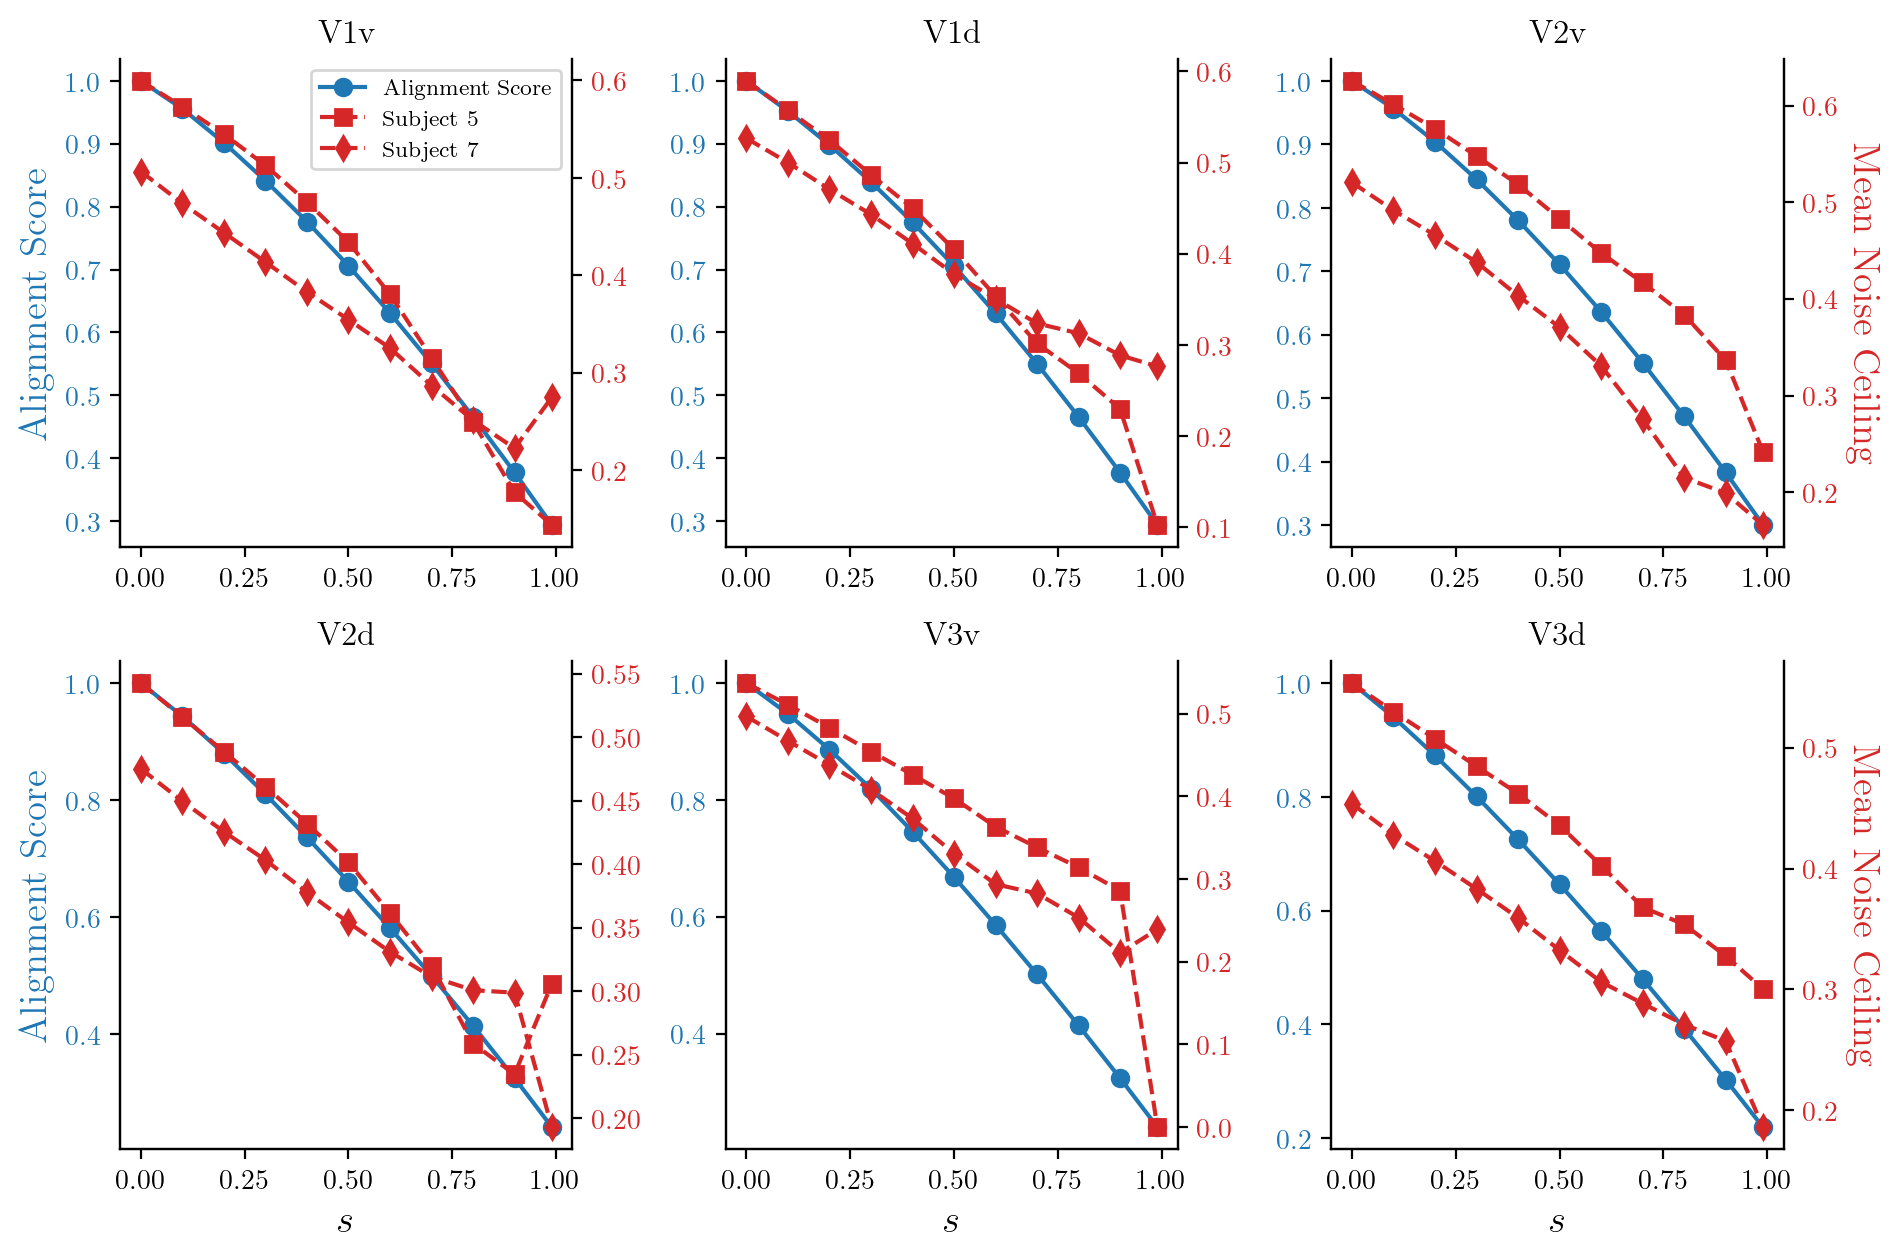

In [35]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    mreg_dict_partial = align_voxel_responses(responses1=r1, responses2=r2)
    mreg_dict_partial = compute_noise_ceilings(mreg_dict=mreg_dict_partial,
                                          noise_thresh=0.4,
                                          transform_thresh=1e-8,
                                          base_path=base_path,
                                          brain_region=region, 
                                          subj1=subj1,
                                          subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_partial.keys()))
    alignment_scores = np.array([mreg_dict_partial[m]['score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_partial[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_partial[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        #ax1.set_xlabel(r'$m_\mathrm{reg}$')
        ax1.set_xlabel(r'$s$', fontsize=14)
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Score', color=color1, fontsize=14)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)
    #auc = np.trapezoid(alignment_scores, mreg_values)
    #ax1.text(0.98, 0.95, fr"AUC: ${auc:.2f}$", transform=ax1.transAxes,
    #         ha='right', va='top', color=color1, fontsize=9)

    # right y-axis: mean noise ceiling values
    color2 = 'tab:red'
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Ceiling', rotation=-90, labelpad=15, fontsize=14, color=color2)
    
    
    #color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=fr'Subject ${subj1}$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color2, label=fr'Subject ${subj2}$')
    ax2.tick_params(axis='y', labelcolor=color2)

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()
plt.savefig(f'./paper-figures/nsd-noise-ceiling-subjects5-7.png', dpi=300)

plt.show()

# correlation-based ordering of voxels on soft-match

In [8]:
def pairwise_correlation(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    compute the pairwise correlation between x and y
    """
    xm = x - torch.mean(x, dim=0, keepdim=True)
    ym = y - torch.mean(y, dim=0, keepdim=True)
    corr_matrix = (xm.T @ ym) / (
        torch.sqrt(torch.sum(xm**2, dim=0, keepdim=True)).T
        * torch.sqrt(torch.sum(ym**2, dim=0, keepdim=True))
    )

    # we care about unit-unit matching
    return torch.diag(corr_matrix)

In [9]:
def align_voxel_responses_both(responses1, responses2):
    mreg_values = np.arange(0, 1.1, 0.1)
    mreg_values = np.where(mreg_values == 1.0, 0.99, mreg_values)  
    mreg_dict = {m: {'unbalanced_score': None, 
                     'sm_score': None,
                     'unbalanced_transform': None,
                     'sm_transform': None,
                     'mean_dropped_nc_subj1': None, 
                     'mean_dropped_nc_subj2': None, 
                     'mean_nc_subj1': None,
                     'mean_nc_subj2': None} for m in mreg_values}

    soft_match = SoftMatch()
    #sm_score = np.mean(np.array(soft_match.fit_kfold_score(torch.tensor(responses1), 
    #                                                    torch.tensor(responses2))))
    sm_score = np.mean(np.array(soft_match.fit_score(torch.tensor(responses1), 
                                                        torch.tensor(responses2))))
    
    for m in tqdm(mreg_dict.keys()):
        unbalanced_sm = UnbalancedSoftMatch(mass_reg=m)
        #score = np.mean(np.array(unbalanced_sm.fit_kfold_score(torch.tensor(responses1), torch.tensor(responses2))))
        score = np.mean(np.array(unbalanced_sm.fit_score(torch.tensor(responses1), torch.tensor(responses2))))
        mreg_dict[m]['unbalanced_score'] = score
        mreg_dict[m]['sm_score'] = sm_score
        mreg_dict[m]['unbalanced_transform'] = unbalanced_sm.transform
        mreg_dict[m]['sm_transform'] = soft_match.transform

    return mreg_dict

In [11]:
def compute_noise_ceilings_both(mreg_dict, 
                                noise_thresh: float,
                                transform_thresh: float,
                                base_path: str,
                                brain_region: str,
                                responses1: np.ndarray,
                                responses2: np.ndarray,
                                subj1: int,
                                subj2: int):
    # load noise ceilings
    nc_subject1 = np.load(f'{base_path}{brain_region}_data/nc_0{subj1}.npy')
    nc_subject2 = np.load(f'{base_path}{brain_region}_data/nc_0{subj2}.npy')

    # identify and average low noise-ceiling voxels
    low_nc_subj1 = nc_subject1[nc_subject1 < noise_thresh]
    low_nc_subj2 = nc_subject2[nc_subject2 < noise_thresh]
    mean_low_nc_subj1 = low_nc_subj1.mean() if low_nc_subj1.size else np.nan
    mean_low_nc_subj2 = low_nc_subj2.mean() if low_nc_subj2.size else np.nan

    # get voxel counts from the unbalanced_transform matrix 
    U0 = mreg_dict[0.0]['unbalanced_transform']
    n_vox1, n_vox2 = U0.shape

    # instantiate metric class
    soft_match = SoftMatch()

    # loop over each mreg
    for mreg, data in mreg_dict.items():
        U = data['unbalanced_transform']
        sm = data['sm_transform']

        # sanity checks
        assert U.shape == (n_vox1, n_vox2), \
            f"unbalanced_transform shape {U.shape} != ({n_vox1},{n_vox2})"
        assert sm.shape == (n_vox1, n_vox2), \
            f"sm_transform shape {sm.shape} != ({n_vox1},{n_vox2})"

        # which voxels were effectively "kept" by the unbalanced transform?
        kept_vox1 = torch.where(U.sum(dim=1) >= transform_thresh)[0].numpy()
        kept_vox2 = torch.where(U.sum(dim=0) >= transform_thresh)[0].numpy()
        n_kept1, n_kept2 = kept_vox1.size, kept_vox2.size

        # transform responses and compute correlations
        R1 = torch.tensor(responses1, dtype=torch.float32)  # (stim, vox1)
        R2 = torch.tensor(responses2, dtype=torch.float32)  # (stim, vox2)

        # subj1 -> subj2 space
        T12 = R1 @ sm                           # (stim, vox2)
        corr12 = pairwise_correlation(x=T12, y=R2)  # (vox2,)
        # drop the bottom-n_kept2 least-correlated -> these are the worst matches
        worst2 = corr12.argsort()[:n_kept2]

        # subj2 -> subj1 space
        T21 = R2 @ sm.T                         # (stim, vox1)
        corr21 = pairwise_correlation(x=T21, y=R1)  # (vox1,)
        worst1 = corr21.argsort()[:n_kept1]

        print(f'worst1: {worst1.shape}; worst2: {worst2.shape}')

        # compute mean noise ceilings of these worst‐matched voxels
        mean_worst_nc1 = (nc_subject1[worst1.numpy()].mean()
                          if worst1.numel() else np.nan)
        mean_worst_nc2 = (nc_subject2[worst2.numpy()].mean()
                          if worst2.numel() else np.nan)

        # recompute soft‐match score on high noise-ceiling voxels only
        if n_kept1 > 0 and n_kept2 > 0:
            resp1_high = torch.tensor(responses1[:, worst1])
            resp2_high = torch.tensor(responses2[:, worst2])
            print(f'worst1: {worst1.shape}; worst2: {worst2.shape}')
            print(f'high1: {resp1_high.shape}; high2: {resp2_high.shape}')
            #resp1_high = torch.tensor(responses1[:, best1])
            #resp2_high = torch.tensor(responses2[:, best2])
          
            #scores = soft_match.fit_kfold_score(resp1_high, resp2_high)
            scores = soft_match.fit_score(resp1_high, resp2_high)
            sm_score_high_nc = float(np.mean(np.array(scores)))
        else:
            sm_score_high_nc = 1

        # store both the global low‐nc means and the worst‐matched means
        data['mean_nc_subj1']         = mean_low_nc_subj1
        data['mean_nc_subj2']         = mean_low_nc_subj2
        data['mean_dropped_nc_subj1'] = mean_worst_nc1
        data['mean_dropped_nc_subj2'] = mean_worst_nc2
        data['sm_score'] = sm_score_high_nc

    return mreg_dict

In [12]:
def compute_noise_ceilings_both(mreg_dict: dict,
                                noise_thresh: float,
                                transform_thresh: float, 
                                base_path: str,
                                brain_region: str, 
                                responses1: np.ndarray,
                                responses2: np.ndarray,
                                subj1: int, 
                                subj2: int):
    nc1 = np.load(f'{base_path}{brain_region}_data/nc_0{subj1}.npy')
    nc2 = np.load(f'{base_path}{brain_region}_data/nc_0{subj2}.npy')

    # mean noise-ceiling of voxels *below* noise_thresh
    low1 = nc1[nc1 < noise_thresh]
    low2 = nc2[nc2 < noise_thresh]
    mean_low1 = low1.mean() if low1.size else np.nan
    mean_low2 = low2.mean() if low2.size else np.nan

    n_vox1, n_vox2 = responses1.shape[-1], responses2.shape[-1]

    softmatch = SoftMatch()

    # loop over all mreg values
    for mreg, data in mreg_dict.items():
        U  = data['unbalanced_transform']   # [n_vox1 x n_vox2]
        SM = data['sm_transform']           # [n_vox1 x n_vox2]

        # sanity check
        assert U.shape == (n_vox1, n_vox2)
        assert SM.shape == (n_vox1, n_vox2)
        
        # how many voxels are kept using partial matching?
        kept1 = torch.where(U.sum(dim=1) >= transform_thresh)[0]
        kept2 = torch.where(U.sum(dim=0) >= transform_thresh)[0]
        k1, k2 = kept1.numel(), kept2.numel()


        # transform responses from subj1 -> subj2
        t12 = torch.tensor(responses1, dtype=torch.float32) @ SM # [n_stim, n_vox2]
        corr12 = pairwise_correlation(t12, torch.tensor(responses2, dtype=torch.float32)) # [n_vox2]
        kept_2 = corr12.argsort(descending=True)[:k2]
        dropped_2 = corr12.argsort(descending=False)[:n_vox2-k2]

        # transform responses from subj2 -> subj1
        t21 = torch.tensor(responses2, dtype=torch.float32) @ SM.T # [n_stim, n_vox1]
        corr21 = pairwise_correlation(t21, torch.tensor(responses1, dtype=torch.float32)) # [n_vox1]
        kept_1 = corr21.argsort(descending=True)[:k1]
        dropped_1 = corr21.argsort(descending=False)[:n_vox1-k1]

        # compute mean noise ceiling of dropped indices
        mean_drop_nc1 = nc1[list(dropped_1)].mean() if len(list(dropped_1)) > 0 else 0
        mean_drop_nc2 = nc2[list(dropped_2)].mean() if len(list(dropped_2)) > 0 else 0

        # select voxel indices with higher correlation
        sub1 = torch.tensor(r1)[:, kept_1]
        sub2 = torch.tensor(r2)[:, kept_2]
    
        # recompute soft-match on the remaining voxels
        if sub1.shape[-1] == 0 or sub2.shape[-1] == 0:
            sm_score = 1
        else:
            sm = SoftMatch()
            #sm_score = np.mean(np.array(sm.fit_kfold_score(sub1, sub2)))
            sm_score = np.mean(np.array(sm.fit_score(sub1, sub2)))

        data['mean_nc_subj1']         = mean_low1
        data['mean_nc_subj2']         = mean_low2
        data['mean_dropped_nc_subj1'] = mean_drop_nc1
        data['mean_dropped_nc_subj2'] = mean_drop_nc2
        data['sm_score']              = sm_score

    
    return mreg_dict

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:42<00:00, 17.07s/it]


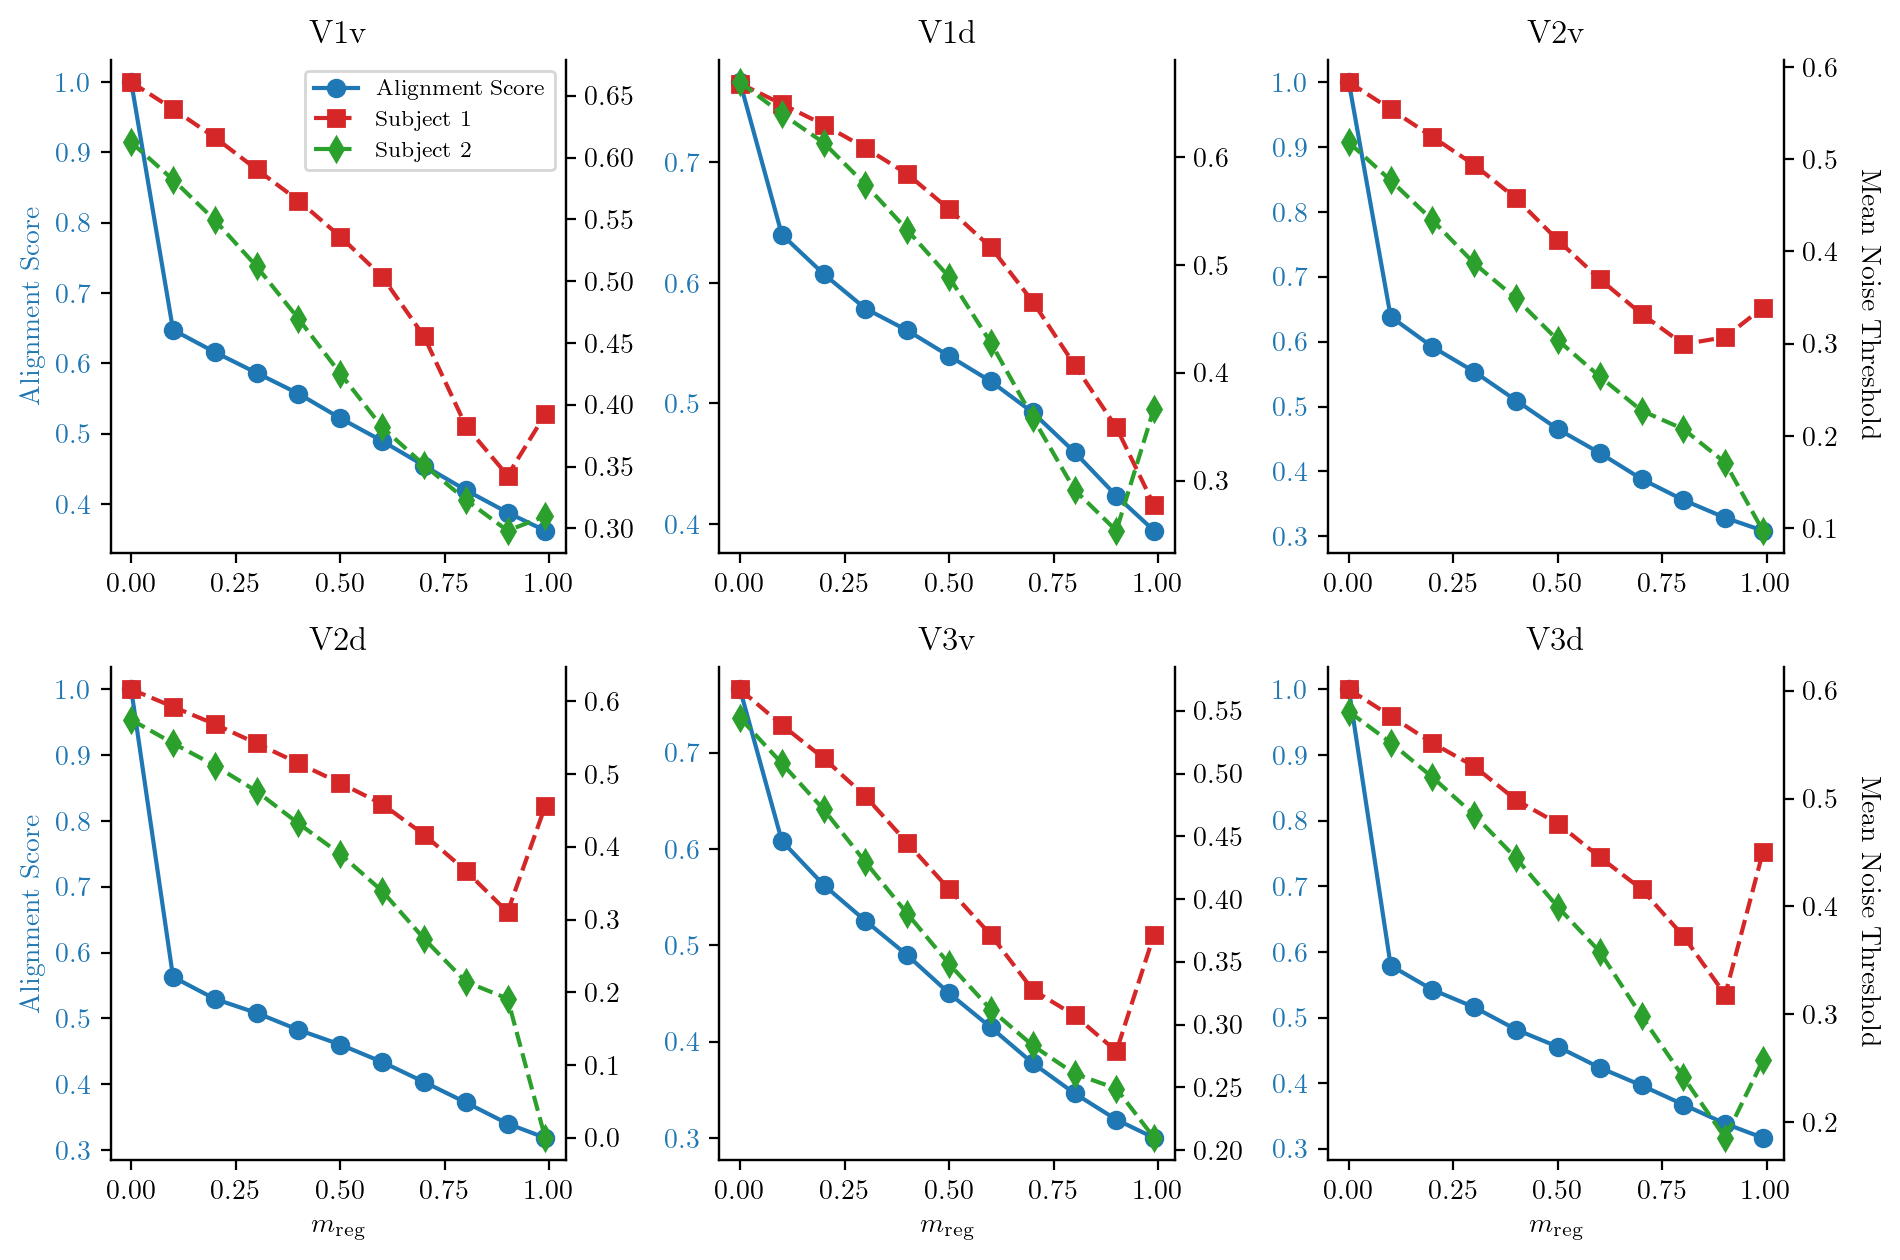

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    mreg_dict_corr = align_voxel_responses_both(responses1=r1, responses2=r2)
    mreg_dict_corr = compute_noise_ceilings_both(mreg_dict=mreg_dict_corr,
                                            noise_thresh=0.4, 
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_corr.keys()))
    alignment_scores = np.array([mreg_dict_corr[m]['sm_score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_corr[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_corr[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        ax1.set_xlabel(r'$m_\mathrm{reg}$')
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Score', color=color1, fontsize=10)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)

    # right y-axis: mean noise ceiling values
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Threshold', rotation=-90, labelpad=15, fontsize=10)
    
    color2 = 'tab:red'
    color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=r'Subject $1$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color3, label=r'Subject $2$')
    ax2.tick_params(axis='y')

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()

plt.show()

# brute force ordering of neurons

In [13]:
def brute_force_matching(z1: torch.tensor, z2: torch.tensor) -> dict:
    """
    brute force mathching of neurons in a representation pair
    """
    # we want to store the indices of the neurons deleted
    delta_dict = {k: None for k in range(z1.shape[-1])}
    sm = SoftMatch()
    mean_sm = np.mean(np.array(sm.fit_score(z1, z2)))

    # remove each neuron and see how the score is impacted
    # we want to repeat this over N neurons
    for neuron_idx in tqdm(range(z1.shape[-1]), 
                           position=0,
                           leave=True):
        if neuron_idx == 0:
            candidate = z1[:,1:]
        elif neuron_idx == z1.shape[1] - 1:
            candidate = z1[:, :-1]
        else:
            candidate = torch.cat([
                z1[:, :neuron_idx],
                z1[:, neuron_idx+1:]
            ], dim=1)

        # refit soft-matching to the augmented representation
        score = torch.tensor(sm.fit_score(candidate, z2))
        new_score = score
        delta = (new_score - mean_sm).item()

        delta_dict[neuron_idx] = delta

    # return a (descending) rank-ordered list of units in terms of decrease in correlation
    sorted_delta_dict = {k: v for k, v in sorted(delta_dict.items(), 
                                                 key=lambda item: item[1],
                                                 reverse=False)}

    return sorted_delta_dict

In [14]:
def compute_noise_ceilings_brute_force(mreg_dict: dict,
                                delta_dicts: Tuple[dict, dict],
                                transform_thresh: float, 
                                base_path: str,
                                brain_region: str, 
                                responses1: np.ndarray,
                                responses2: np.ndarray,
                                subj1: int, 
                                subj2: int):
    nc1 = np.load(f'{base_path}{brain_region}_data/nc_0{subj1}.npy')
    nc2 = np.load(f'{base_path}{brain_region}_data/nc_0{subj2}.npy')

    delta_dict_forward, delta_dict_backward = delta_dicts
    forward_index_ordering = list(delta_dict_forward.keys())
    backward_index_ordering = list(delta_dict_backward.keys())

    n_vox1, n_vox2 = responses1.shape[-1], responses2.shape[-1]

    softmatch = SoftMatch()

    # loop over all mreg values
    for mreg, data in mreg_dict.items():
        U  = data['unbalanced_transform']   # [n_vox1 x n_vox2]
        SM = data['sm_transform']

        # sanity check
        assert U.shape == (n_vox1, n_vox2)
        
        # how many voxels are kept using partial matching?
        kept1 = torch.where(U.sum(dim=1) >= transform_thresh)[0]
        kept2 = torch.where(U.sum(dim=0) >= transform_thresh)[0]
        k1, k2 = kept1.numel(), kept2.numel()

        # augment responses to refit soft-matching
        #r1_augmented = r1[:, forward_index_ordering[:k1]]
        #r2_augmented = r2[:, backward_index_ordering[:k2]]
        print(max(forward_index_ordering), max(backward_index_ordering), SM.shape)

        if k1 == 0 or k2 == 0:
            sm_score = 1
        else:
            _ = softmatch.fit(responses1, responses2)
            augmented_sm_transform = softmatch.transform.detach().clone()
            augmented_sm_transform[forward_index_ordering[::-1][:n_vox1-k1],:] = 0
            augmented_sm_transform[:,backward_index_ordering[::-1][:n_vox2-k2]] = 0
            sm_score = 1 - torch.nansum(augmented_sm_transform * softmatch.cost).item()
            #softmatch.transform = augmented_sm_transform
            #sm_score = softmatch.score(r1, r2)
            #sm_score = np.mean(np.array(softmatch.fit_kfold_score(r1_augmented, r2_augmented)))

        print(f'score: {sm_score}')
        # mean noise ceilings of dropped indices
        dropped_1 = forward_index_ordering[::-1][:n_vox1-k1]
        dropped_2 = backward_index_ordering[::-1][:n_vox2-k2]
        mean_drop_nc1 = nc1[list(dropped_1)].mean() if len(list(dropped_1)) > 0 else 0
        mean_drop_nc2 = nc2[list(dropped_2)].mean() if len(list(dropped_2)) > 0 else 0

        print(mean_drop_nc1, mean_drop_nc2)

        data['mean_dropped_nc_subj1'] = mean_drop_nc1
        data['mean_dropped_nc_subj2'] = mean_drop_nc2
        data['sm_score']              = sm_score
    
    return mreg_dict

  0%|                                                                                                                                                                                                                   | 0/6 [00:06<?, ?it/s]


KeyboardInterrupt: 

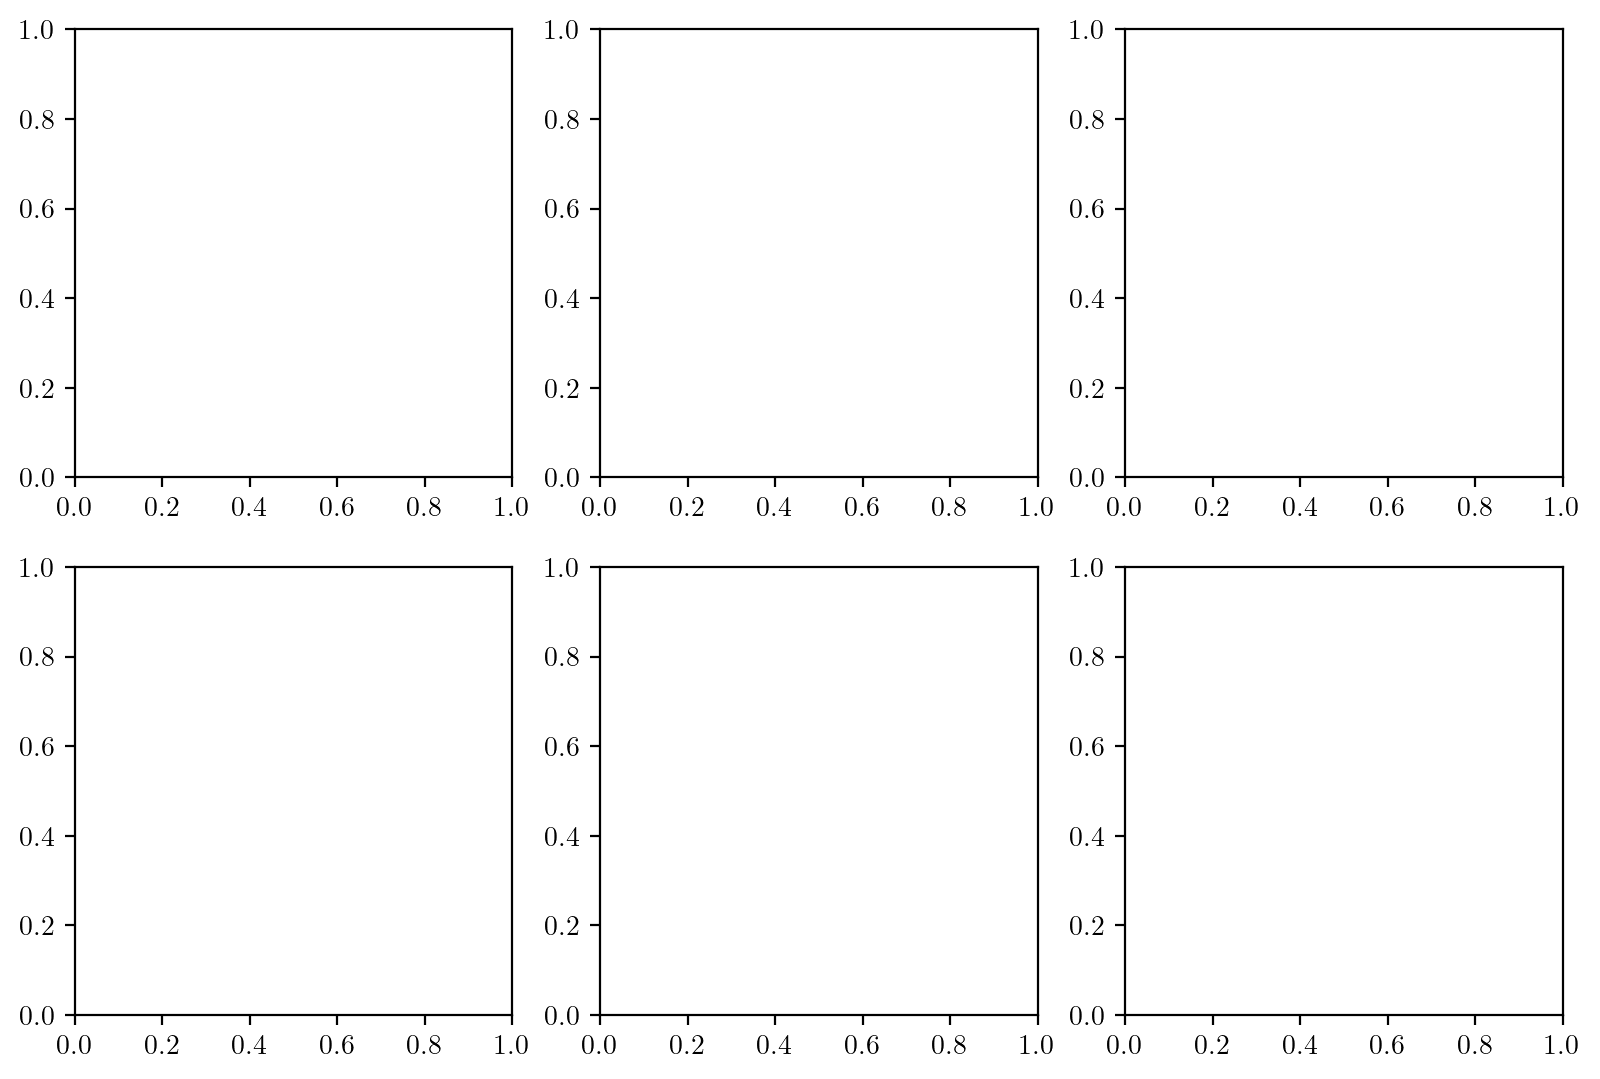

In [18]:
# i would like to compute the raw ordering of units 
# in a response pair and then use this to remove units and 
# refit a transport plan. this is slightly more involved than before
# because with this method, we are getting an ordering of neurons
# this would not be symmetric, so we repeat the process bidirectionally
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    # rank ordering of subject 1 -> subject 2
    delta_dict_forward = brute_force_matching(torch.tensor(r1), 
                                              torch.tensor(r2))

    # rank ordering of subject 2 -> subject 1
    delta_dict_backward = brute_force_matching(torch.tensor(r2), 
                                               torch.tensor(r1))

    mreg_dict_brute_force = align_voxel_responses_both(responses1=r1, responses2=r2)

    mreg_dict_brute_force = compute_noise_ceilings_brute_force(mreg_dict=mreg_dict_brute_force,
                                            delta_dicts=(delta_dict_forward, delta_dict_backward),
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_brute_force.keys()))
    alignment_scores = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_brute_force[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_brute_force[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        ax1.set_xlabel(r'$m_\mathrm{reg}$')
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Score', color=color1, fontsize=10)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)

    # right y-axis: mean noise ceiling values
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Threshold', rotation=-90, labelpad=15, fontsize=10)
    
    color2 = 'tab:red'
    color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=r'Subject $1$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color3, label=r'Subject $2$')
    ax2.tick_params(axis='y')

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()

plt.show()
    

# overlay correlations for all approaches

In [21]:
mreg_values = np.arange(0, 1.1, 0.1)
mreg_values = np.where(mreg_values == 1.0, 0.99, mreg_values)  

In [22]:
all_results = {}

for region in tqdm(brain_regions, desc="regions"):
    result = {}
    # load and gather responses
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)

    #result['responses'] = {'r1': r1, 'r2': r2}

    # brute force forward/backward (rankings)
    delta_dict_forward = brute_force_matching(torch.tensor(r1), torch.tensor(r2))
    delta_dict_backward = brute_force_matching(torch.tensor(r2), torch.tensor(r1))
    result['delta_forward'] = delta_dict_forward
    result['delta_backward'] = delta_dict_backward

    # brute force matching + noise ceilings
    mreg_dict_brute_force = align_voxel_responses_both(responses1=r1, responses2=r2)
    mreg_dict_brute_force = compute_noise_ceilings_brute_force(
        mreg_dict=mreg_dict_brute_force,
        delta_dicts=(delta_dict_forward, delta_dict_backward),
        transform_thresh=1e-8,
        base_path=base_path,
        brain_region=region,
        responses1=r1,
        responses2=r2,
        subj1=subj1,
        subj2=subj2
    )
    result['mreg_brute_force'] = mreg_dict_brute_force

    # correlation matching + noise ceilings
    mreg_dict_corr = align_voxel_responses_both(responses1=r1, responses2=r2)
    mreg_dict_corr = compute_noise_ceilings_both(
        mreg_dict=mreg_dict_corr,
        noise_thresh=0.4,
        transform_thresh=1e-8,
        base_path=base_path,
        brain_region=region,
        responses1=r1,
        responses2=r2,
        subj1=subj1,
        subj2=subj2
    )
    result['mreg_corr'] = mreg_dict_corr

    # partial Wasserstein-based matching
    mreg_dict_partial = align_voxel_responses(responses1=r1, responses2=r2)
    result['mreg_partial'] = mreg_dict_partial

    # store region result
    all_results[region] = result

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 544/544 [03:19<00:00,  2.72it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:09<00:00,  1.11it/s]


593 543 torch.Size([594, 544])
score: 1
0.6610054578849951 0.6122978467406137
593 543 torch.Size([594, 544])
score: 0.9975982254514524
0.642345173040557 0.5842749368363648
593 543 torch.Size([594, 544])
score: 0.9688438177096806
0.6198032427302322 0.5552721878843299
593 543 torch.Size([594, 544])
score: 0.9247295141647341
0.5946944993800998 0.5219752316172018
593 543 torch.Size([594, 544])
score: 0.8684272247198422
0.5654585099172139 0.4813903966935326
593 543 torch.Size([594, 544])
score: 0.8150451238317015
0.5325848343737146 0.43176407242675846
593 543 torch.Size([594, 544])
score: 0.7433728075792856
0.4978008103821013 0.38152469947173384
593 543 torch.Size([594, 544])
score: 0.655856412752899
0.4562057258461357 0.34797890773263446
593 543 torch.Size([594, 544])
score: 0.5706812049828532
0.410228679225546 0.31514948643644075
593 543 torch.Size([594, 544])
score: 0.4834745350105978
0.3864871246582493 0.2723632849489466
593 543 torch.Size([594, 544])
score: 0.3718883331560854
0.3772006


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:05<00:00,  2.00it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 558/558 [04:32<00:00,  2.05it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:13<00:00,  1.24s/it]


755 557 torch.Size([756, 558])
score: 1.0
0.6680299504056618 0.6694155898169589
755 557 torch.Size([756, 558])
score: 1.0
0.6516752450686315 0.6430302904625494
755 557 torch.Size([756, 558])
score: 0.9909820012206879
0.6346693315838258 0.6177556330597158
755 557 torch.Size([756, 558])
score: 0.9548141232844847
0.614070181707242 0.5871625044636705
755 557 torch.Size([756, 558])
score: 0.8971751644602369
0.5883125235768809 0.5449149136881226
755 557 torch.Size([756, 558])
score: 0.8311847567749827
0.5549329942081405 0.5019349041064416
755 557 torch.Size([756, 558])
score: 0.7588322730510344
0.52241845175816 0.4282969595239082
755 557 torch.Size([756, 558])
score: 0.6760034555323753
0.4797989076271942 0.35967337970638047
755 557 torch.Size([756, 558])
score: 0.5955748089344828
0.4496520472632039 0.29730272977543143
755 557 torch.Size([756, 558])
score: 0.5050207748723685
0.42007170331002414 0.25850450279646514
755 557 torch.Size([756, 558])
score: 0.40310936680004394
0.27758639300388116 0


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  5.80it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 615/615 [02:42<00:00,  3.80it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:09<00:00,  1.17it/s]


...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  5.85it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 566/566 [02:38<00:00,  3.58it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:07<00:00,  1.46it/s]


645 565 torch.Size([646, 566])
score: 1.0
0.5670953711690871 0.5444341726654031
645 565 torch.Size([646, 566])
score: 0.988744457602743
0.5402056119524088 0.5091261825379615
645 565 torch.Size([646, 566])
score: 0.9538972542990329
0.5125448414597417 0.47183026627060914
645 565 torch.Size([646, 566])
score: 0.9011315919308752
0.4862303610278547 0.4284050905775402
645 565 torch.Size([646, 566])
score: 0.8422698879419865
0.45056916723468543 0.3874200436041051
645 565 torch.Size([646, 566])
score: 0.7747235980712819
0.41528453856595576 0.34768922189148754
645 565 torch.Size([646, 566])
score: 0.6966246252912007
0.38427401837752573 0.31214891341816176
645 565 torch.Size([646, 566])
score: 0.6185523984946673
0.34328129481686565 0.28003489079846516
645 565 torch.Size([646, 566])
score: 0.5266474591536463
0.3124520493658921 0.2499716036121645
645 565 torch.Size([646, 566])
score: 0.42145390702364294
0.29694800420116235 0.2332867310566325
645 565 torch.Size([646, 566])
score: 0.3068882708128553


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:02<00:00,  4.32it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 531/531 [03:27<00:00,  2.56it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:05<00:00,  2.13it/s]


540 530 torch.Size([541, 531])
score: 1
0.6012301187859539 0.5805477679972548
540 530 torch.Size([541, 531])
score: 0.9924198541689961
0.5789847055879969 0.552869197318775
540 530 torch.Size([541, 531])
score: 0.9574311289311043
0.5575752647624728 0.5230362577704382
540 530 torch.Size([541, 531])
score: 0.9141791967496378
0.5391951944193749 0.488374168262622
540 530 torch.Size([541, 531])
score: 0.8499639517943604
0.5093011065707126 0.4520175196749973
540 530 torch.Size([541, 531])
score: 0.7828310388096364
0.4857466395299236 0.4108341457871861
540 530 torch.Size([541, 531])
score: 0.7058313870475363
0.4576911779264367 0.36675454939400287
540 530 torch.Size([541, 531])
score: 0.6283367240066531
0.42866212320538244 0.30240315474193374
540 530 torch.Size([541, 531])
score: 0.5249743714332737
0.3916223628629009 0.24033317946774305
540 530 torch.Size([541, 531])
score: 0.425830572632925
0.36191817242285595 0.22426519418424157
540 530 torch.Size([541, 531])
score: 0.32574782551572934
0.3409


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:05<00:00,  1.94it/s]

regions: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [50:15<00:00, 502.63s/it]


In [ ]:
mreg_dict_partial.keys()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 544/544 [02:43<00:00,  3.33it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  8.82it/s]


593 543 torch.Size([594, 544])
score: 1
0.6610054578849951 0.6122978467406137
593 543 torch.Size([594, 544])
score: 0.9975982254514524
0.642345173040557 0.5842749368363648
593 543 torch.Size([594, 544])
score: 0.9688438177096806
0.6198032427302322 0.5552721878843299
593 543 torch.Size([594, 544])
score: 0.9247295141647341
0.5946944993800998 0.5219752316172018
593 543 torch.Size([594, 544])
score: 0.8684272247198422
0.5654585099172139 0.4813903966935326
593 543 torch.Size([594, 544])
score: 0.8150451238317015
0.5325848343737146 0.43176407242675846
593 543 torch.Size([594, 544])
score: 0.7433728075792856
0.4978008103821013 0.38152469947173384
593 543 torch.Size([594, 544])
score: 0.655856412752899
0.4562057258461357 0.34797890773263446
593 543 torch.Size([594, 544])
score: 0.5706812049828532
0.410228679225546 0.31514948643644075
593 543 torch.Size([594, 544])
score: 0.4834745350105978
0.3864871246582493 0.2723632849489466
593 543 torch.Size([594, 544])
score: 0.3718883331560854
0.3772006


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  9.40it/s]

 17%|█████████████████████████████████▋                                                                                                                                                                        | 1/6 [05:49<29:06, 349.38s/it]

[0.96824473 0.92893838 0.88225628 0.82909702 0.76804563 0.69957379
 0.62389709 0.54146224 0.45324965 0.36986185] [0.64771214 0.61603785 0.58646469 0.55696946 0.52210962 0.48970205
 0.45477784 0.41985654 0.38794289 0.36215944] [0.99759823 0.96884382 0.92472951 0.86842722 0.81504512 0.74337281
 0.65585641 0.5706812  0.48347454 0.37188833]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 558/558 [02:00<00:00,  4.64it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  8.89it/s]


...

[0.96331193 0.91657154 0.86209084 0.80013683 0.72975947 0.65269594
 0.56959891 0.48254343 0.39242202 0.30876005] [0.60843359 0.56269891 0.52542918 0.48975531 0.45025805 0.41469277
 0.37769715 0.34628631 0.31902871 0.30014054] [0.98874446 0.95389725 0.90113159 0.84226989 0.7747236  0.69662463
 0.6185524  0.52664746 0.42145391 0.30688827]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 531/531 [01:23<00:00,  6.33it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.79it/s]


540 530 torch.Size([541, 531])
score: 1
0.6012301187859539 0.5805477679972548
540 530 torch.Size([541, 531])
score: 0.9924198541689961
0.5789847055879969 0.552869197318775
540 530 torch.Size([541, 531])
score: 0.9574311289311043
0.5575752647624728 0.5230362577704382
540 530 torch.Size([541, 531])
score: 0.9141791967496378
0.5391951944193749 0.488374168262622
540 530 torch.Size([541, 531])
score: 0.8499639517943604
0.5093011065707126 0.4520175196749973
540 530 torch.Size([541, 531])
score: 0.7828310388096364
0.4857466395299236 0.4108341457871861
540 530 torch.Size([541, 531])
score: 0.7058313870475363
0.4576911779264367 0.36675454939400287
540 530 torch.Size([541, 531])
score: 0.6283367240066531
0.42866212320538244 0.30240315474193374
540 530 torch.Size([541, 531])
score: 0.5249743714332737
0.3916223628629009 0.24033317946774305
540 530 torch.Size([541, 531])
score: 0.425830572632925
0.36191817242285595 0.22426519418424157
540 530 torch.Size([541, 531])
score: 0.32574782551572934
0.3409


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:02<00:00,  5.34it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [25:02<00:00, 250.34s/it]


[0.96056767 0.91264927 0.85900762 0.79848535 0.73203252 0.65920912
 0.58118744 0.49766752 0.40859092 0.32474663] [0.57919334 0.54229977 0.51565603 0.4816758  0.45537953 0.42361285
 0.39660924 0.3673943  0.33834407 0.31678236] [0.99241985 0.95743113 0.9141792  0.84996395 0.78283104 0.70583139
 0.62833672 0.52497437 0.42583057 0.32574783]


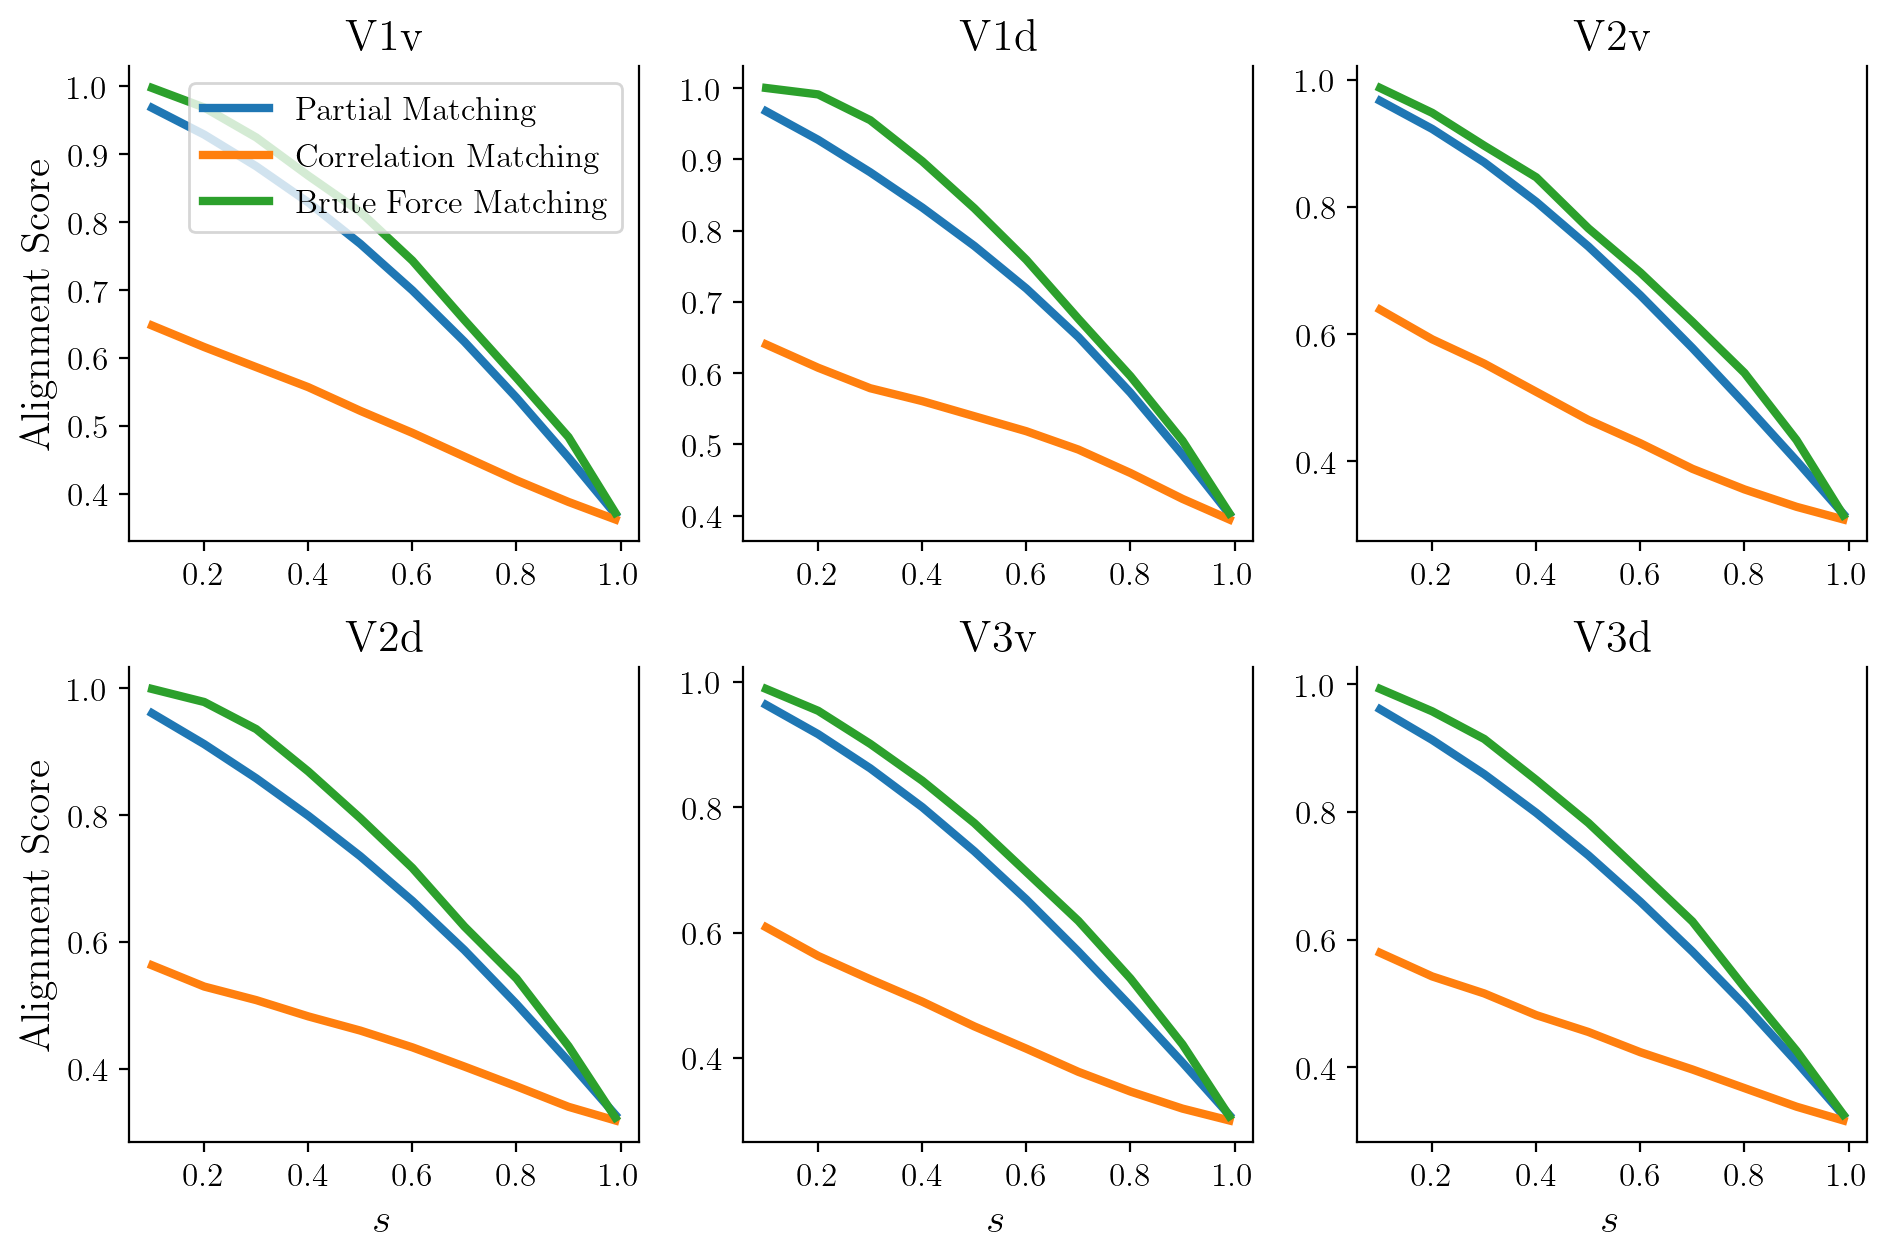

In [23]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    # rank ordering of subject 1 -> subject 2
    ##### all matching types
    delta_dict_forward = brute_force_matching(torch.tensor(r1), 
                                              torch.tensor(r2))

    # rank ordering of subject 2 -> subject 1
    delta_dict_backward = brute_force_matching(torch.tensor(r2), 
                                                   torch.tensor(r1))

    # brute force matching
    mreg_dict_brute_force = align_voxel_responses_both(responses1=r1, responses2=r2)
    mreg_dict_brute_force = compute_noise_ceilings_brute_force(mreg_dict=mreg_dict_brute_force,
                                            delta_dicts=(delta_dict_forward, delta_dict_backward),
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)
    # correlation matching
    mreg_dict_corr = align_voxel_responses_both(responses1=r1, responses2=r2)
    mreg_dict_corr = compute_noise_ceilings_both(mreg_dict=mreg_dict_corr,
                                            noise_thresh=0.4, 
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)
    # partial wasserstein-based matching
    mreg_dict_partial = align_voxel_responses(responses1=r1, responses2=r2)
    

    #####
    
    alignment_partial = np.array([mreg_dict_partial[m]['score'] for m in mreg_values[1:]])
    alignment_corr = np.array([mreg_dict_corr[m]['sm_score'] for m in mreg_values[1:]])
    alignment_brute_force = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values[1:]])

    #print(alignment_partial, alignment_corr, alignment_brute_force)

    ax1 = axes[i]  # select subplot
    print(alignment_partial, alignment_corr, alignment_brute_force)
    
    # left y-axis: alignment score
    if i > 2:
        #axes[i].set_xlabel(r'$m_\mathrm{reg}$', fontsize=15)
        axes[i].set_xlabel(r"$s$", fontsize=15)
    if i == 0 or i == 3:
        axes[i].set_ylabel('Alignment Score', fontsize=15)
    axes[i].plot(mreg_values[1:], alignment_partial, linestyle='-', linewidth=3., label='Partial Matching')
    axes[i].plot(mreg_values[1:], alignment_corr, linestyle='-', linewidth=3., label='Correlation Matching')
    axes[i].plot(mreg_values[1:], alignment_brute_force, linestyle='-', linewidth=3., label='Brute Force Matching')
    axes[i].tick_params(axis='both', labelsize=12)
    ax1.spines['top'].set_visible(False)

    # brain region name
    axes[i].set_title(region, fontsize=16, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = axes[i].get_legend_handles_labels()
        axes[i].legend(lines1, labels1, loc='best', fontsize=12)

fig.tight_layout()

plt.savefig(f'./paper-figures/nsd-matching-baselines.png', dpi=300)
plt.show()
    

# use euclidean cost

In [15]:
# align voxel responses for different regularization values
def align_voxel_responses_euclidean(responses1, responses2):
    mreg_values = np.arange(0, 1.1, 0.1)
    mreg_values = np.where(mreg_values == 1.0, 0.99, mreg_values)  
    
    mreg_dict = {m: {'score': None, 
                     'transform': None,
                     'iou_subj1': None,
                     'iou_subj2': None, 
                     'mean_dropped_nc_subj1': None, 
                     'mean_dropped_nc_subj2': None, 
                     'mean_nc_subj1': None,
                     'mean_nc_subj2': None} for m in mreg_values}
    
    for m in tqdm(mreg_dict.keys()):
        metric = UnbalancedSoftMatch(mass_reg=m, cost_type='euclidean')
        #score = np.mean(np.array(metric.fit_kfold_score(torch.tensor(responses1), torch.tensor(responses2))))\
        score = np.mean(np.array(metric.fit_score(torch.tensor(responses1), torch.tensor(responses2))))
        mreg_dict[m]['score'] = score
        mreg_dict[m]['transform'] = metric.transform

    return mreg_dict

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:09<00:00,  1.61s/it]


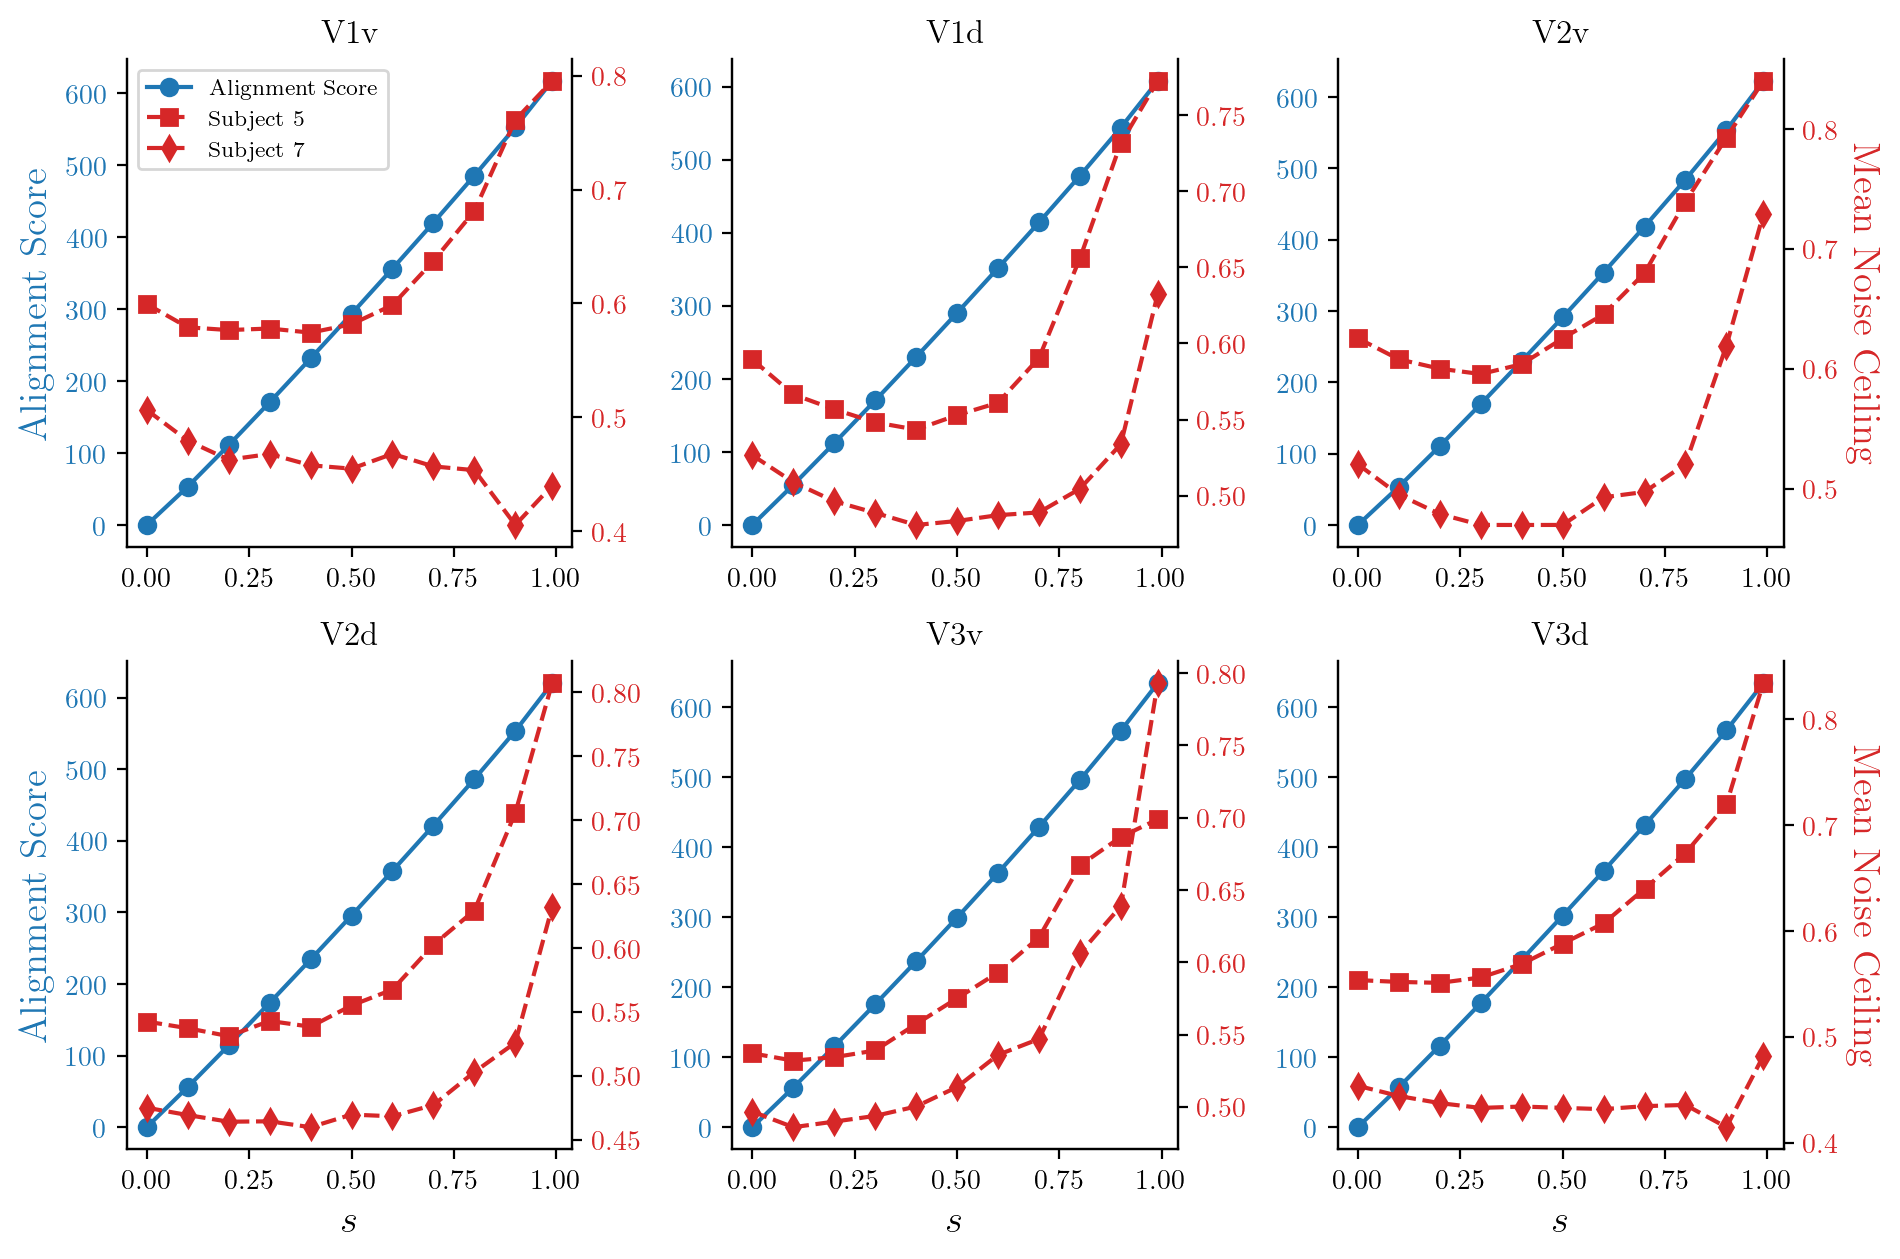

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    mreg_dict_partial = align_voxel_responses_euclidean(responses1=r1, responses2=r2)
    mreg_dict_partial = compute_noise_ceilings(mreg_dict=mreg_dict_partial,
                                          noise_thresh=0.4,
                                          transform_thresh=1e-8,
                                          base_path=base_path,
                                          brain_region=region, 
                                          subj1=subj1,
                                          subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_partial.keys()))
    alignment_scores = np.array([mreg_dict_partial[m]['score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_partial[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_partial[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        #ax1.set_xlabel(r'$m_\mathrm{reg}$')
        ax1.set_xlabel(r'$s$', fontsize=14)
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Score', color=color1, fontsize=14)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)
    #auc = np.trapezoid(alignment_scores, mreg_values)
    #ax1.text(0.98, 0.95, fr"AUC: ${auc:.2f}$", transform=ax1.transAxes,
    #         ha='right', va='top', color=color1, fontsize=9)

    # right y-axis: mean noise ceiling values
    color2 = 'tab:red'
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Ceiling', rotation=-90, labelpad=15, fontsize=14, color=color2)
    
    
    #color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=fr'Subject ${subj1}$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color2, label=fr'Subject ${subj2}$')
    ax2.tick_params(axis='y', labelcolor=color2)

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()
#plt.savefig(f'./paper-figures/nsd-noise-ceiling-subjects5-7.png', dpi=300)

plt.show()

In [17]:
subj1 = 1
subj2 = 2

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:31<00:00,  5.23s/it]


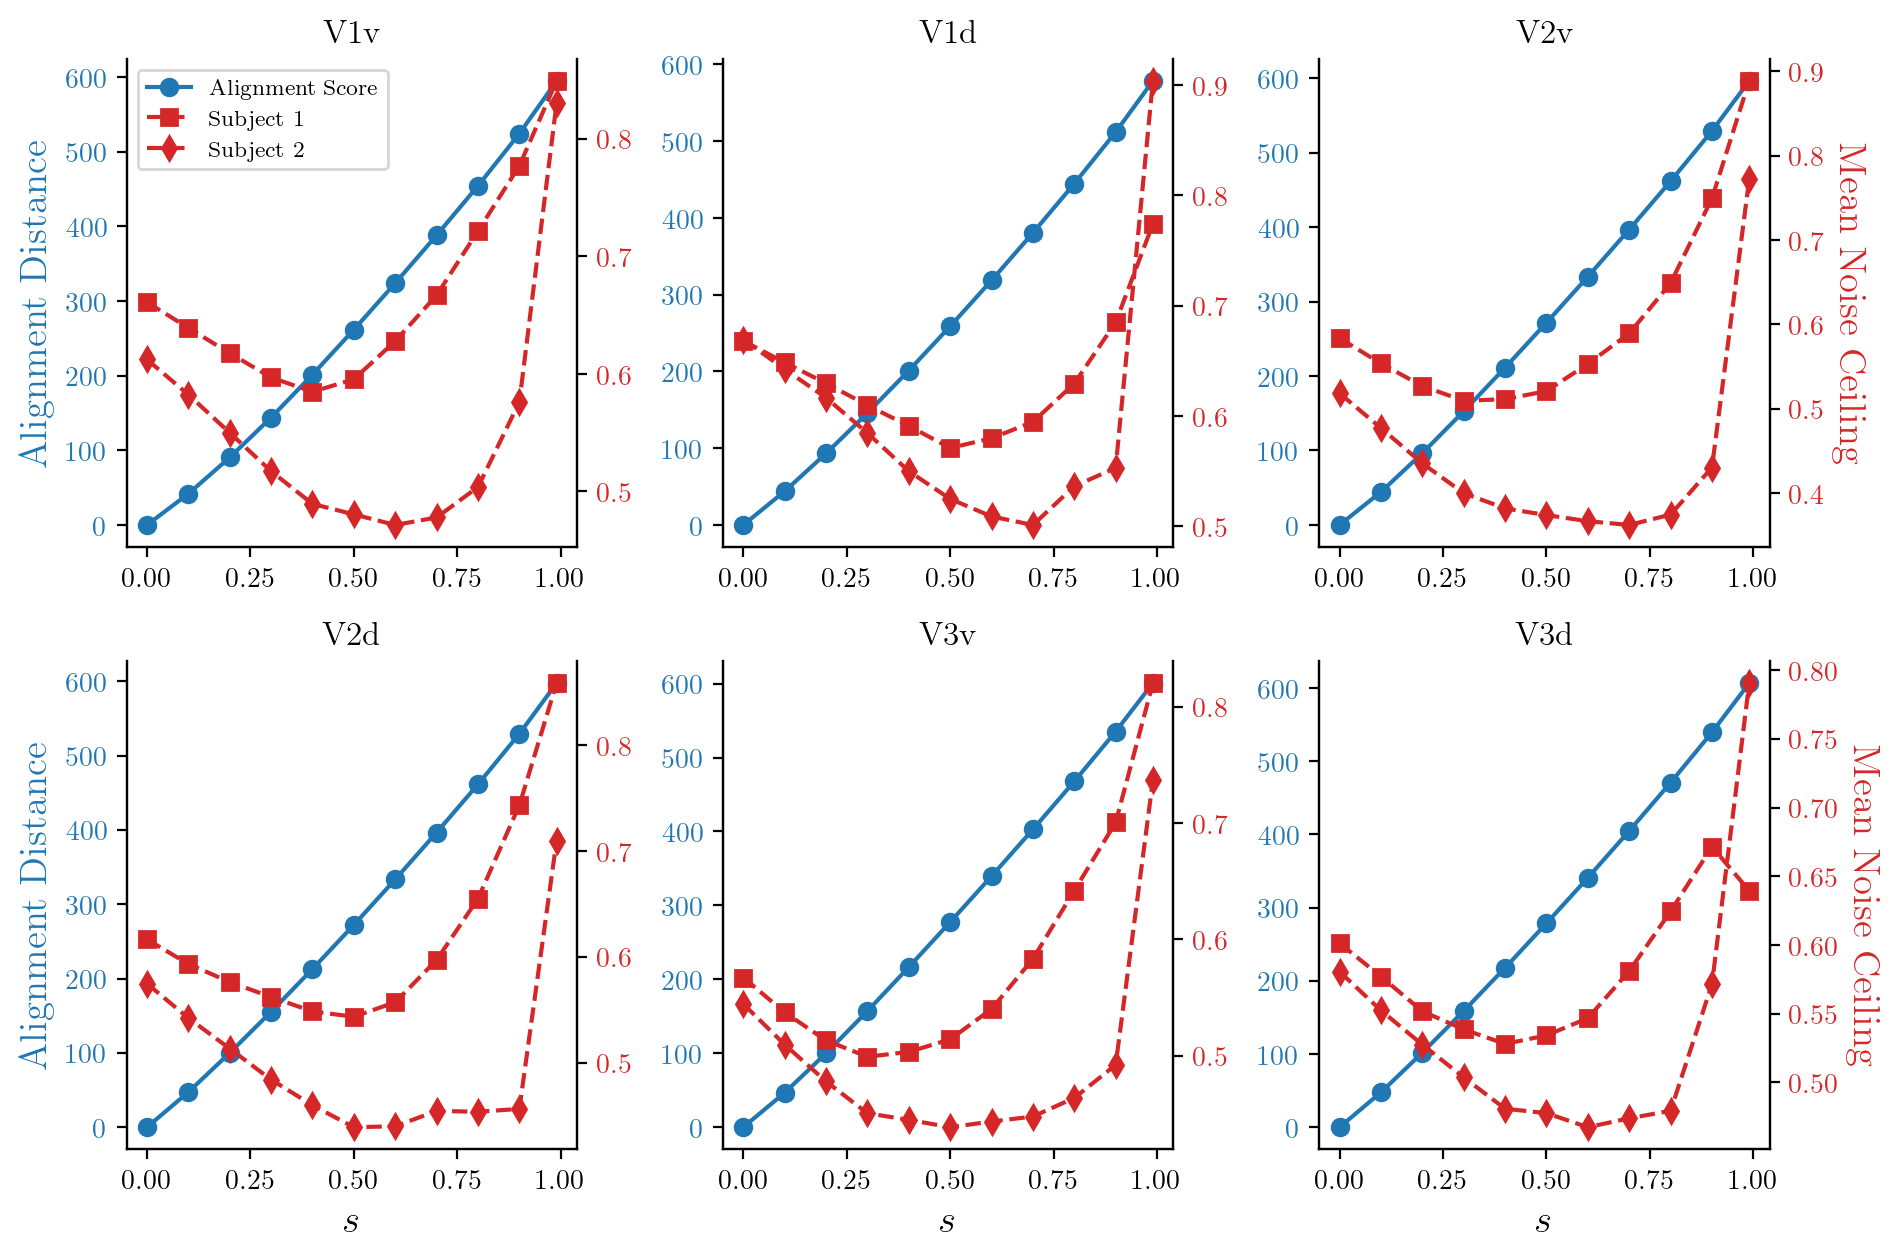

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    mreg_dict_partial = align_voxel_responses_euclidean(responses1=r1, responses2=r2)
    mreg_dict_partial = compute_noise_ceilings(mreg_dict=mreg_dict_partial,
                                          noise_thresh=0.4,
                                          transform_thresh=1e-8,
                                          base_path=base_path,
                                          brain_region=region, 
                                          subj1=subj1,
                                          subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_partial.keys()))
    alignment_scores = np.array([mreg_dict_partial[m]['score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_partial[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_partial[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        #ax1.set_xlabel(r'$m_\mathrm{reg}$')
        ax1.set_xlabel(r'$s$', fontsize=14)
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Distance', color=color1, fontsize=14)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)
    #auc = np.trapezoid(alignment_scores, mreg_values)
    #ax1.text(0.98, 0.95, fr"AUC: ${auc:.2f}$", transform=ax1.transAxes,
    #         ha='right', va='top', color=color1, fontsize=9)

    # right y-axis: mean noise ceiling values
    color2 = 'tab:red'
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Ceiling', rotation=-90, labelpad=15, fontsize=14, color=color2)
    
    
    #color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=fr'Subject ${subj1}$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color2, label=fr'Subject ${subj2}$')
    ax2.tick_params(axis='y', labelcolor=color2)

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()
#plt.savefig(f'./paper-figures/nsd-noise-ceiling-subjects5-7.png', dpi=300)

plt.show()

In [18]:
def align_voxel_responses_both_euclidean(responses1, responses2):
    mreg_values = np.arange(0, 1.1, 0.1)
    mreg_values = np.where(mreg_values == 1.0, 0.99, mreg_values)  
    mreg_dict = {m: {'unbalanced_score': None, 
                     'sm_score': None,
                     'unbalanced_transform': None,
                     'sm_transform': None,
                     'mean_dropped_nc_subj1': None, 
                     'mean_dropped_nc_subj2': None, 
                     'mean_nc_subj1': None,
                     'mean_nc_subj2': None} for m in mreg_values}

    soft_match = SoftMatch(cost_type='euclidean')
    sm_score = np.mean(np.array(soft_match.fit_score(torch.tensor(responses1), 
                                                        torch.tensor(responses2))))
    
    for m in tqdm(mreg_dict.keys()):
        unbalanced_sm = UnbalancedSoftMatch(mass_reg=m, cost_type='euclidean')
        #score = np.mean(np.array(unbalanced_sm.fit_kfold_score(torch.tensor(responses1), torch.tensor(responses2))))
        score = np.mean(np.array(unbalanced_sm.fit_score(torch.tensor(responses1), torch.tensor(responses2))))
        mreg_dict[m]['unbalanced_score'] = score
        mreg_dict[m]['sm_score'] = sm_score
        mreg_dict[m]['unbalanced_transform'] = unbalanced_sm.transform
        mreg_dict[m]['sm_transform'] = soft_match.transform

    return mreg_dict

In [19]:
def compute_noise_ceilings_both_euclidean(mreg_dict: dict,
                                noise_thresh: float,
                                transform_thresh: float, 
                                base_path: str,
                                brain_region: str, 
                                responses1: np.ndarray,
                                responses2: np.ndarray,
                                subj1: int, 
                                subj2: int):
    nc1 = np.load(f'{base_path}{brain_region}_data/nc_0{subj1}.npy')
    nc2 = np.load(f'{base_path}{brain_region}_data/nc_0{subj2}.npy')

    # mean noise-ceiling of voxels *below* noise_thresh
    low1 = nc1[nc1 < noise_thresh]
    low2 = nc2[nc2 < noise_thresh]
    mean_low1 = low1.mean() if low1.size else np.nan
    mean_low2 = low2.mean() if low2.size else np.nan

    n_vox1, n_vox2 = responses1.shape[-1], responses2.shape[-1]

    softmatch = SoftMatch(cost_type='euclidean')

    # loop over all mreg values
    for mreg, data in mreg_dict.items():
        U  = data['unbalanced_transform']   # [n_vox1 x n_vox2]
        SM = data['sm_transform']           # [n_vox1 x n_vox2]

        # sanity check
        assert U.shape == (n_vox1, n_vox2)
        assert SM.shape == (n_vox1, n_vox2)
        
        # how many voxels are kept using partial matching?
        kept1 = torch.where(U.sum(dim=1) >= transform_thresh)[0]
        kept2 = torch.where(U.sum(dim=0) >= transform_thresh)[0]
        k1, k2 = kept1.numel(), kept2.numel()


        # transform responses from subj1 -> subj2
        t12 = torch.tensor(responses1, dtype=torch.float32) @ SM # [n_stim, n_vox2]
        corr12 = pairwise_correlation(t12, torch.tensor(responses2, dtype=torch.float32)) # [n_vox2]
        kept_2 = corr12.argsort(descending=True)[:k2]
        dropped_2 = corr12.argsort(descending=False)[:n_vox2-k2]

        # transform responses from subj2 -> subj1
        t21 = torch.tensor(responses2, dtype=torch.float32) @ SM.T # [n_stim, n_vox1]
        corr21 = pairwise_correlation(t21, torch.tensor(responses1, dtype=torch.float32)) # [n_vox1]
        kept_1 = corr21.argsort(descending=True)[:k1]
        dropped_1 = corr21.argsort(descending=False)[:n_vox1-k1]

        # compute mean noise ceiling of dropped indices
        mean_drop_nc1 = nc1[list(dropped_1)].mean() if len(list(dropped_1)) > 0 else 0
        mean_drop_nc2 = nc2[list(dropped_2)].mean() if len(list(dropped_2)) > 0 else 0

        # select voxel indices with higher correlation
        sub1 = torch.tensor(r1)[:, kept_1]
        sub2 = torch.tensor(r2)[:, kept_2]
    
        # recompute soft-match on the remaining voxels
        if sub1.shape[-1] == 0 or sub2.shape[-1] == 0:
            sm_score = 1
        else:
            sm = SoftMatch(cost_type='euclidean')
            #sm_score = np.mean(np.array(sm.fit_kfold_score(sub1, sub2)))
            sm_score = np.mean(np.array(sm.fit_score(sub1, sub2)))

        data['mean_nc_subj1']         = mean_low1
        data['mean_nc_subj2']         = mean_low2
        data['mean_dropped_nc_subj1'] = mean_drop_nc1
        data['mean_dropped_nc_subj2'] = mean_drop_nc2
        data['sm_score']              = sm_score

    
    return mreg_dict

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:11<00:00,  1.89s/it]


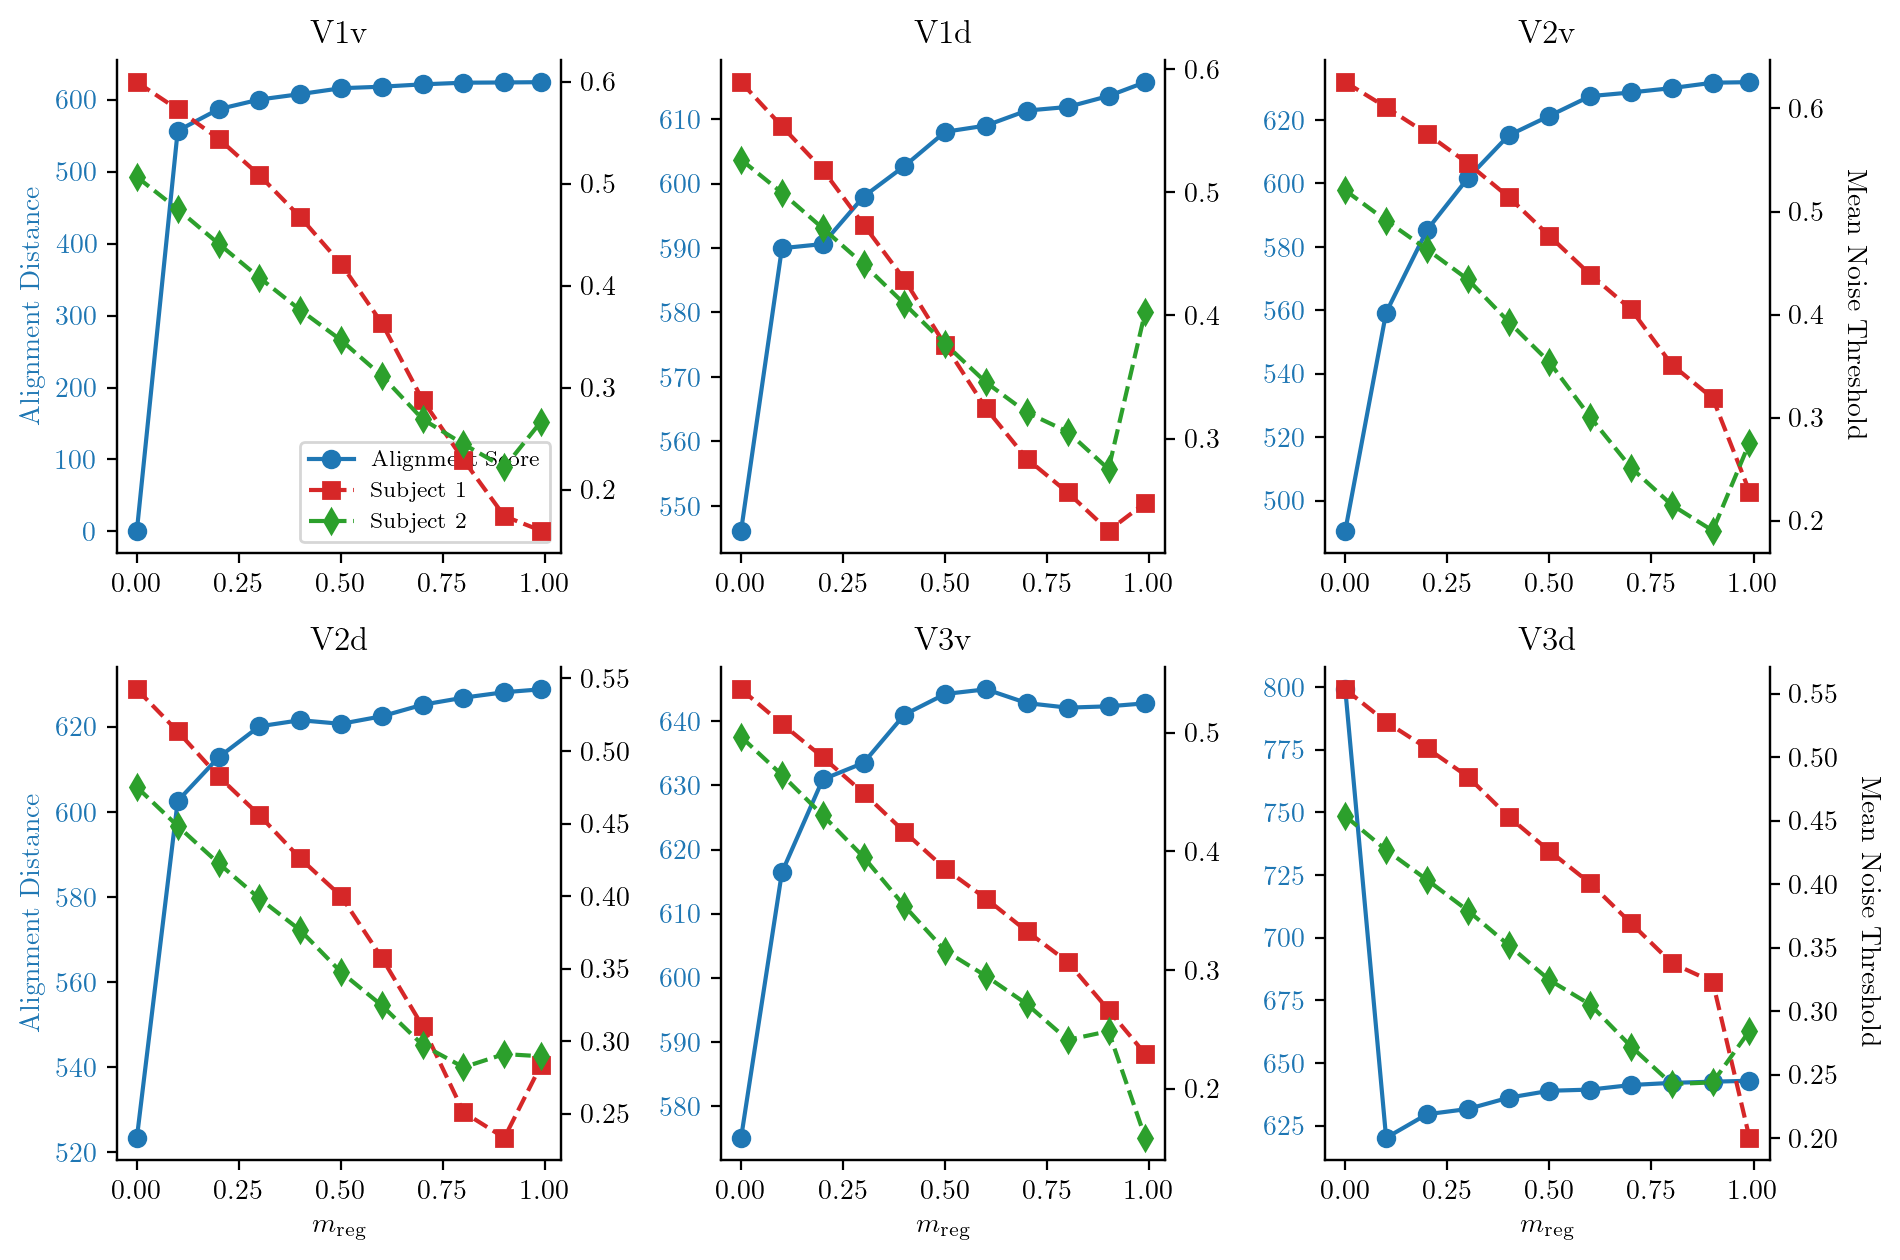

In [21]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    mreg_dict_corr = align_voxel_responses_both_euclidean(responses1=r1, responses2=r2)
    mreg_dict_corr = compute_noise_ceilings_both_euclidean(mreg_dict=mreg_dict_corr,
                                            noise_thresh=0.4, 
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_corr.keys()))
    alignment_scores = np.array([mreg_dict_corr[m]['sm_score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_corr[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_corr[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        ax1.set_xlabel(r'$m_\mathrm{reg}$')
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Distance', color=color1, fontsize=10)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)

    # right y-axis: mean noise ceiling values
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Threshold', rotation=-90, labelpad=15, fontsize=10)
    
    color2 = 'tab:red'
    color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=r'Subject $1$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color3, label=r'Subject $2$')
    ax2.tick_params(axis='y')

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()

plt.show()

In [20]:
def brute_force_matching_euclidean(z1: torch.tensor, z2: torch.tensor) -> dict:
    """
    brute force mathching of neurons in a representation pair
    """
    # we want to store the indices of the neurons deleted
    delta_dict = {k: None for k in range(z1.shape[-1])}
    sm = SoftMatch(cost_type='euclidean')
    mean_sm = np.mean(np.array(sm.fit_score(z1, z2)))

    # remove each neuron and see how the score is impacted
    # we want to repeat this over N neurons
    for neuron_idx in tqdm(range(z1.shape[-1]), 
                           position=0,
                           leave=True):
        if neuron_idx == 0:
            candidate = z1[:,1:]
        elif neuron_idx == z1.shape[1] - 1:
            candidate = z1[:, :-1]
        else:
            candidate = torch.cat([
                z1[:, :neuron_idx],
                z1[:, neuron_idx+1:]
            ], dim=1)

        # refit soft-matching to the augmented representation
        score = torch.tensor(sm.fit_score(candidate, z2))
        new_score = score
        delta = (new_score - mean_sm).item()

        delta_dict[neuron_idx] = delta

    # return a (descending) rank-ordered list of units in terms of decrease in correlation
    sorted_delta_dict = {k: v for k, v in sorted(delta_dict.items(), 
                                                 key=lambda item: item[1],
                                                 reverse=False)}

    return sorted_delta_dict

In [21]:
def compute_noise_ceilings_brute_force_euclidean(mreg_dict: dict,
                                delta_dicts: Tuple[dict, dict],
                                transform_thresh: float, 
                                base_path: str,
                                brain_region: str, 
                                responses1: np.ndarray,
                                responses2: np.ndarray,
                                subj1: int, 
                                subj2: int):
    nc1 = np.load(f'{base_path}{brain_region}_data/nc_0{subj1}.npy')
    nc2 = np.load(f'{base_path}{brain_region}_data/nc_0{subj2}.npy')

    delta_dict_forward, delta_dict_backward = delta_dicts
    forward_index_ordering = list(delta_dict_forward.keys())
    backward_index_ordering = list(delta_dict_backward.keys())

    n_vox1, n_vox2 = responses1.shape[-1], responses2.shape[-1]

    softmatch = SoftMatch(cost_type='euclidean')

    # loop over all mreg values
    for mreg, data in mreg_dict.items():
        U  = data['unbalanced_transform']   # [n_vox1 x n_vox2]
        SM = data['sm_transform']

        # sanity check
        assert U.shape == (n_vox1, n_vox2)
        
        # how many voxels are kept using partial matching?
        kept1 = torch.where(U.sum(dim=1) >= transform_thresh)[0]
        kept2 = torch.where(U.sum(dim=0) >= transform_thresh)[0]
        k1, k2 = kept1.numel(), kept2.numel()

        # augment responses to refit soft-matching
        #r1_augmented = r1[:, forward_index_ordering[:k1]]
        #r2_augmented = r2[:, backward_index_ordering[:k2]]
        print(max(forward_index_ordering), max(backward_index_ordering), SM.shape)

        if k1 == 0 or k2 == 0:
            sm_score = 1
        else:
            _ = softmatch.fit(responses1, responses2)
            augmented_sm_transform = softmatch.transform.detach().clone()
            augmented_sm_transform[forward_index_ordering[::-1][:n_vox1-k1],:] = 0
            augmented_sm_transform[:,backward_index_ordering[::-1][:n_vox2-k2]] = 0
            sm_score = 1 - torch.nansum(augmented_sm_transform * softmatch.cost).item()
            #softmatch.transform = augmented_sm_transform
            #sm_score = softmatch.score(r1, r2)
            #sm_score = np.mean(np.array(softmatch.fit_kfold_score(r1_augmented, r2_augmented)))

        print(f'score: {sm_score}')
        # mean noise ceilings of dropped indices
        dropped_1 = forward_index_ordering[::-1][:n_vox1-k1]
        dropped_2 = backward_index_ordering[::-1][:n_vox2-k2]
        mean_drop_nc1 = nc1[list(dropped_1)].mean() if len(list(dropped_1)) > 0 else 0
        mean_drop_nc2 = nc2[list(dropped_2)].mean() if len(list(dropped_2)) > 0 else 0

        print(mean_drop_nc1, mean_drop_nc2)

        data['mean_dropped_nc_subj1'] = mean_drop_nc1
        data['mean_dropped_nc_subj2'] = mean_drop_nc2
        data['sm_score']              = sm_score
    
    return mreg_dict

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 524/524 [00:42<00:00, 12.24it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 13.87it/s]


457 523 torch.Size([458, 524])
score: 1
0.5994613901176886 0.5065508854006769
457 523 torch.Size([458, 524])
score: -2.20336049612461
0.575034869039371 0.5218250745026183
457 523 torch.Size([458, 524])
score: -9.379539331143668
0.5552922304942486 0.5449753858624581
457 523 torch.Size([458, 524])
score: -30.957422795428847
0.5284082104016193 0.5751690362586275
457 523 torch.Size([458, 524])
score: -79.72401191615876
0.5117991647980962 0.5986427348001765
457 523 torch.Size([458, 524])
score: -143.46432600609091
0.4892873731484808 0.6353591532760942
457 523 torch.Size([458, 524])
score: -223.65248037874142
0.4737060078146731 0.6601773663163883
457 523 torch.Size([458, 524])
score: -329.24516061274164
0.4600708647709835 0.7014402320764836
457 523 torch.Size([458, 524])


 17%|█████████████████████████████████▊                                                                                                                                                                         | 1/6 [01:20<06:43, 80.75s/it]

score: -439.01638384061965
0.4216048761378183 0.7349033421792491
457 523 torch.Size([458, 524])
score: -538.2278107558368
0.41947793826950663 0.7777502375267409
457 523 torch.Size([458, 524])
score: -616.9131670187078
0.3903019307835233 0.7815490906823462


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 618/618 [01:08<00:00,  8.98it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.39it/s]


...

score: -337.7564033512475
0.525636579384676 0.5186268713091854
474 370 torch.Size([475, 371])
score: -432.5102201303277
0.5587090122082977 0.5657487556917087
474 370 torch.Size([475, 371])
score: -539.2623035144429
0.620781645848366 0.6444682189182626
474 370 torch.Size([475, 371])
score: -633.7429134336662
0.7103426621724376 0.7664874639352517


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 355/355 [00:27<00:00, 12.81it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 14.52it/s]


449 354 torch.Size([450, 355])
score: 1.0
0.5533369117534038 0.45425448290100956
449 354 torch.Size([450, 355])
score: -5.153005698733612
0.5307892828047756 0.45749232466875955
449 354 torch.Size([450, 355])
score: -30.812645033610202
0.5194025759114068 0.4594877518693606
449 354 torch.Size([450, 355])
score: -54.633569627461895
0.5094087315144565 0.4638732699777536
449 354 torch.Size([450, 355])
score: -98.41582782132409
0.499466376329536 0.4742761934673481
449 354 torch.Size([450, 355])
score: -169.9895037915415
0.5024939765059945 0.4876483297739247
449 354 torch.Size([450, 355])
score: -241.56663384486458
0.49986398035106 0.49735473018431053
449 354 torch.Size([450, 355])


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [09:06<00:00, 91.02s/it]

score: -353.8904093435793
0.5050429870973316 0.5205263898733544
449 354 torch.Size([450, 355])
score: -441.39665577929736
0.521790730073198 0.5561429818467192
449 354 torch.Size([450, 355])
score: -534.2238816689338
0.5193757033777034 0.6082923484072525
449 354 torch.Size([450, 355])
score: -632.9600220695602
0.5559152439433793 0.6972208386872228


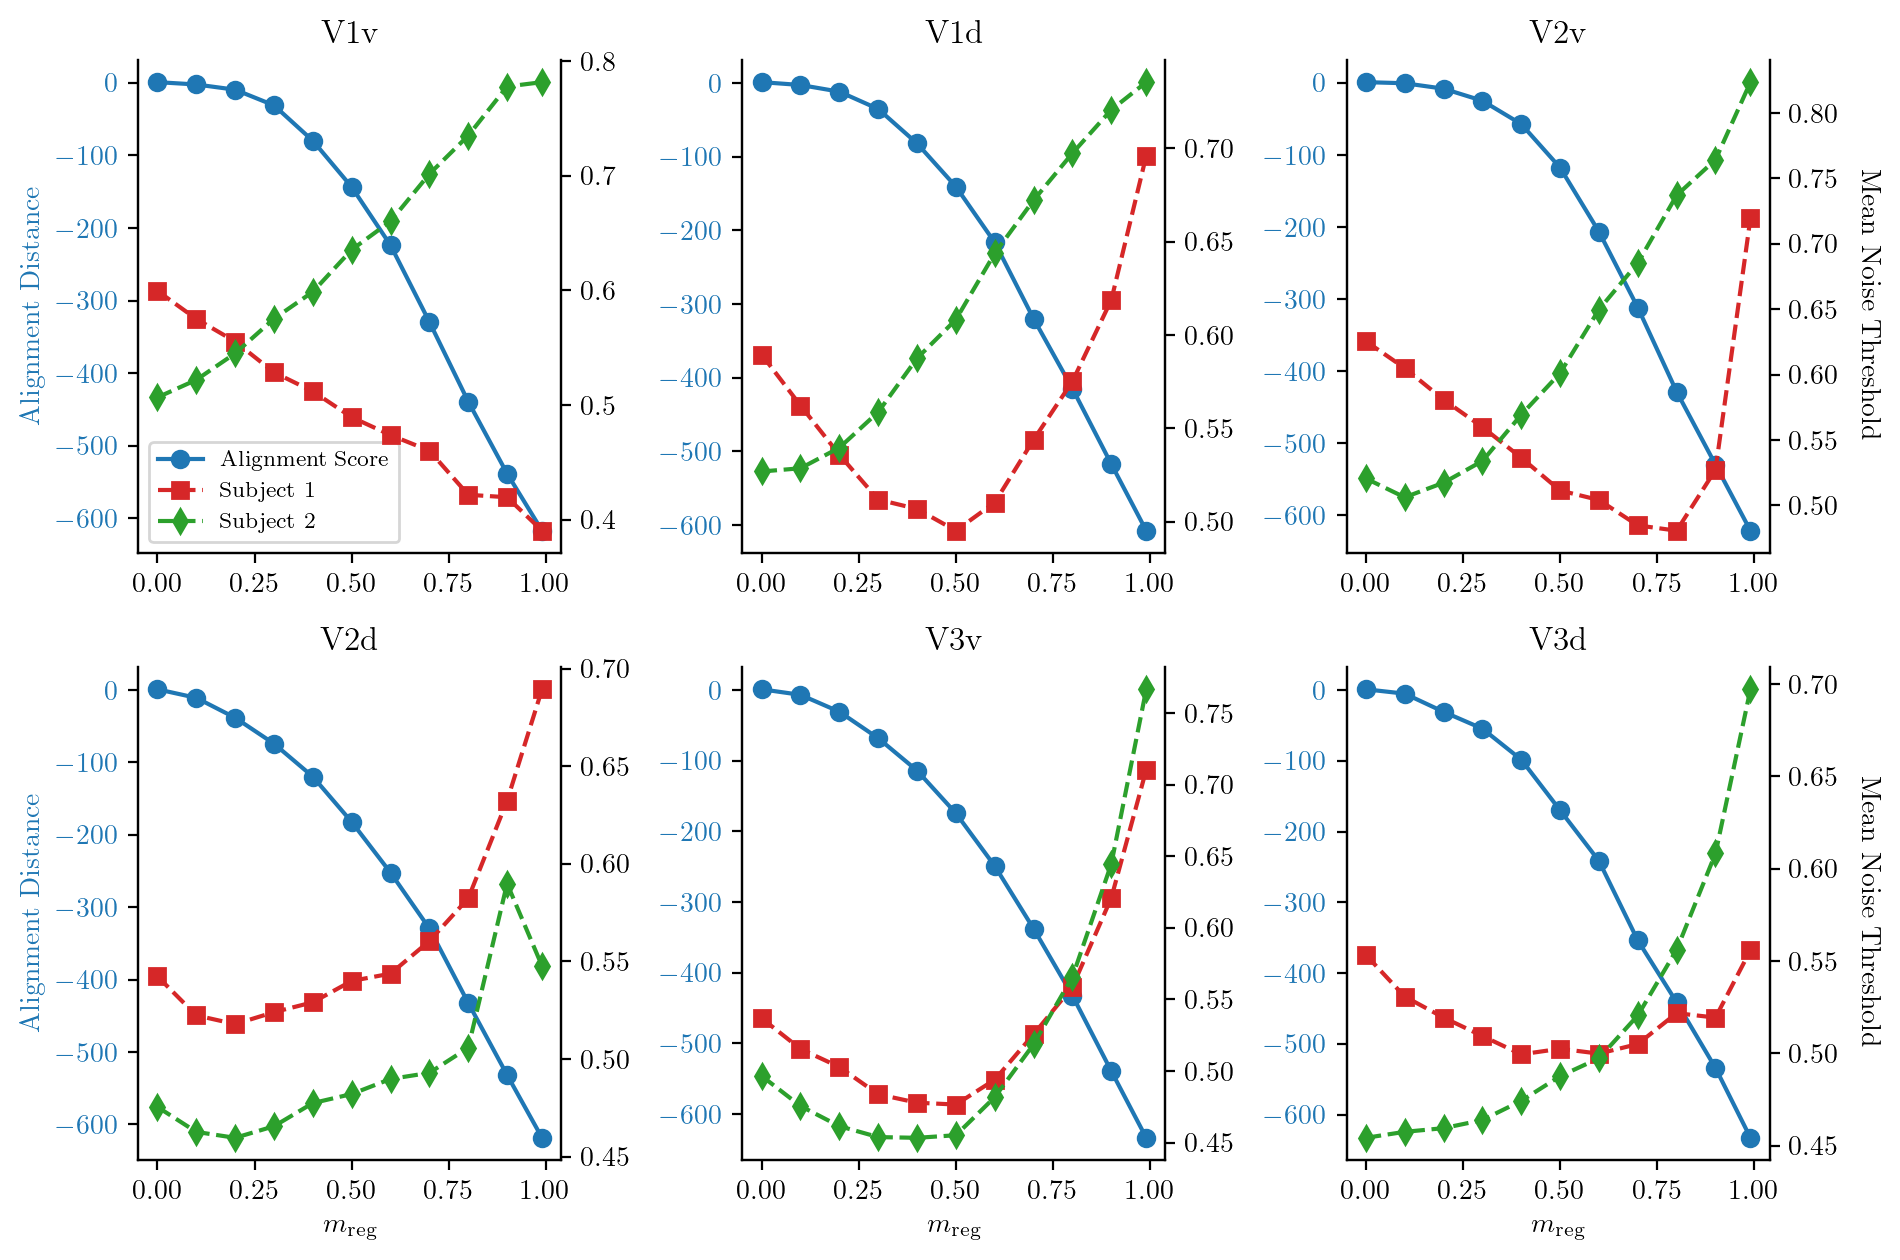

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    # rank ordering of subject 1 -> subject 2
    delta_dict_forward = brute_force_matching_euclidean(torch.tensor(r1), 
                                              torch.tensor(r2))

    # rank ordering of subject 2 -> subject 1
    delta_dict_backward = brute_force_matching_euclidean(torch.tensor(r2), 
                                               torch.tensor(r1))

    mreg_dict_brute_force = align_voxel_responses_both_euclidean(responses1=r1, responses2=r2)

    mreg_dict_brute_force = compute_noise_ceilings_brute_force_euclidean(mreg_dict=mreg_dict_brute_force,
                                            delta_dicts=(delta_dict_forward, delta_dict_backward),
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)

    mreg_values = np.array(sorted(mreg_dict_brute_force.keys()))
    alignment_scores = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values])
    # use the computed mean noise ceilings 
    mean_nc_subj1 = np.array([mreg_dict_brute_force[m]['mean_dropped_nc_subj1'] for m in mreg_values])
    mean_nc_subj2 = np.array([mreg_dict_brute_force[m]['mean_dropped_nc_subj2'] for m in mreg_values])

    ax1 = axes[i]  # select subplot
    
    # left y-axis: alignment score
    color1 = 'tab:blue'
    if i > 2:
        ax1.set_xlabel(r'$m_\mathrm{reg}$')
    if i == 0 or i == 3:
        ax1.set_ylabel('Alignment Distance', color=color1, fontsize=10)
    ax1.plot(mreg_values, alignment_scores, marker='o', linestyle='-', color=color1, label='Alignment Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.spines['top'].set_visible(False)

    # right y-axis: mean noise ceiling values
    ax2 = ax1.twinx()
    ax2.spines['top'].set_visible(False)
    if i == 2 or i == 5:
        ax2.set_ylabel('Mean Noise Threshold', rotation=-90, labelpad=15, fontsize=10)
    
    color2 = 'tab:red'
    color3 = 'tab:green'
    ax2.plot(mreg_values, mean_nc_subj1, marker='s', linestyle='--', color=color2, label=r'Subject $1$')
    ax2.plot(mreg_values, mean_nc_subj2, marker='d', linestyle='--', color=color3, label=r'Subject $2$')
    ax2.tick_params(axis='y')

    # brain region name
    ax1.set_title(region, fontsize=12, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=8)

fig.tight_layout()

plt.show()
    

In [28]:
mreg_values = np.arange(0, 1.1, 0.1)
mreg_values = np.where(mreg_values == 1.0, 0.99, mreg_values)  

In [ ]:
all_results = {}

for region in tqdm(brain_regions, desc="regions"):
    result = {}
    # load and gather responses
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)

    # brute force forward/backward (rankings)
    delta_dict_forward = brute_force_matching_euclidean(torch.tensor(r1), torch.tensor(r2))
    delta_dict_backward = brute_force_matching_euclidean(torch.tensor(r2), torch.tensor(r1))
    result['delta_forward'] = delta_dict_forward
    result['delta_backward'] = delta_dict_backward

    # brute force matching + noise ceilings
    mreg_dict_brute_force = align_voxel_responses_both_euclidean(responses1=r1, responses2=r2)
    mreg_dict_brute_force = compute_noise_ceilings_brute_force_euclidean(
        mreg_dict=mreg_dict_brute_force,
        delta_dicts=(delta_dict_forward, delta_dict_backward),
        transform_thresh=1e-8,
        base_path=base_path,
        brain_region=region,
        responses1=r1,
        responses2=r2,
        subj1=subj1,
        subj2=subj2
    )
    result['mreg_brute_force'] = mreg_dict_brute_force

    # correlation matching + noise ceilings
    mreg_dict_corr = align_voxel_responses_both_euclidean(responses1=r1, responses2=r2)
    mreg_dict_corr = compute_noise_ceilings_both_euclidean(
        mreg_dict=mreg_dict_corr,
        noise_thresh=0.4,
        transform_thresh=1e-8,
        base_path=base_path,
        brain_region=region,
        responses1=r1,
        responses2=r2,
        subj1=subj1,
        subj2=subj2
    )
    result['mreg_corr'] = mreg_dict_corr

    # partial Wasserstein-based matching
    mreg_dict_partial = align_voxel_responses_euclidean(responses1=r1, responses2=r2)
    result['mreg_partial'] = mreg_dict_partial

    # store region result
    all_results[region] = result

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 544/544 [00:48<00:00, 11.12it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12.08it/s]


593 543 torch.Size([594, 544])
score: 1
0.6610054578849953 0.6122978467406137
593 543 torch.Size([594, 544])
score: -3.362342656712322
0.6429671602020683 0.5996827260348588
593 543 torch.Size([594, 544])
score: -15.132950688749382
0.6288881841147966 0.6223086968696797
593 543 torch.Size([594, 544])
score: -40.4619712996867
0.6168185988218765 0.6497826473086284
593 543 torch.Size([594, 544])
score: -94.68814579638139
0.6154349275524574 0.6854517432416455
593 543 torch.Size([594, 544])
score: -165.8604156462909
0.6191945144037067 0.721124939357287
593 543 torch.Size([594, 544])
score: -266.81320687201276
0.654592068295827 0.7497378861039844
593 543 torch.Size([594, 544])
score: -366.5729737637348
0.7328001464520603 0.774924657461327
593 543 torch.Size([594, 544])
score: -445.8949239839884
0.7888445926410756 0.7868646212736622
593 543 torch.Size([594, 544])
score: -529.2736402967189
0.8078055763556219 0.8130580242510652
593 543 torch.Size([594, 544])
score: -596.9037570697084
0.8141762973


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.78it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 558/558 [00:54<00:00, 10.22it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.85it/s]


755 557 torch.Size([756, 558])
score: 1.0
0.6681787559723067 0.6692794975535102
755 557 torch.Size([756, 558])
score: -2.81590938940983
0.6613493624895689 0.6484974628398962
755 557 torch.Size([756, 558])
score: -16.0401211715374
0.661509735910423 0.6618788441808521
755 557 torch.Size([756, 558])
score: -53.63674224978977
0.6724333458415982 0.687450402684481
755 557 torch.Size([756, 558])
score: -108.98042892111155
0.6918937683181523 0.71613648963265
755 557 torch.Size([756, 558])
score: -179.12255720146027
0.7187554370021643 0.7559260423533534
755 557 torch.Size([756, 558])
score: -252.12348737871122
0.7442938641426583 0.7872509856315704
755 557 torch.Size([756, 558])
score: -333.20381108277525
0.7706293457286588 0.8116311147044449
755 557 torch.Size([756, 558])
score: -424.43223763860254
0.7771196650337754 0.8360669129956803
755 557 torch.Size([756, 558])
score: -510.7467938663329
0.7940090486541567 0.8533098577217461
755 557 torch.Size([756, 558])
score: -580.7304687830587
0.8701725


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00, 10.65it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 615/615 [01:11<00:00,  8.57it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  9.91it/s]


833 614 torch.Size([834, 615])
score: 1
0.5834763419638219 0.5181476742254278
833 614 torch.Size([834, 615])
score: -2.325303917513664
0.558962308795913 0.5283404722829372
833 614 torch.Size([834, 615])
score: -12.962376366930329
0.5450177219963405 0.5579985244041828
833 614 torch.Size([834, 615])
score: -40.49327758813909
0.5356765227218065 0.5951255397498186
833 614 torch.Size([834, 615])
score: -98.23615604757077
0.5397399740435317 0.6367841443190075
833 614 torch.Size([834, 615])
score: -177.21180821731798
0.5495535155536339 0.6827245278437976
833 614 torch.Size([834, 615])
score: -274.638657226958
0.5839395354665204 0.7316587631470179
833 614 torch.Size([834, 615])
score: -381.56493103518835
0.6430382364634628 0.7753693652733293
833 614 torch.Size([834, 615])
score: -451.0995327885744
0.7225626691089911 0.7896237438842766
833 614 torch.Size([834, 615])
score: -526.3903096393531
0.7977757401045248 0.7903380220031644
833 614 torch.Size([834, 615])
score: -597.6622905977655
0.8398640


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  9.68it/s]

 55%|██████████████████████████████████████████████████████████████████████████████████                                                                  | 332/599 [00:27<00:22, 12.09it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 524/524 [00:41<00:00, 12.59it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 14.25it/s]


457 523 torch.Size([458, 524])
score: 1
0.5994613901176886 0.5065508854006769
457 523 torch.Size([458, 524])
score: -2.20336049612461
0.575034869039371 0.5218250745026183
457 523 torch.Size([458, 524])
score: -9.379539331143668
0.5552922304942486 0.5449753858624581
457 523 torch.Size([458, 524])
score: -30.957422795428847
0.5284082104016193 0.5751690362586275
457 523 torch.Size([458, 524])
score: -79.72401191615876
0.5117991647980962 0.5986427348001765
457 523 torch.Size([458, 524])
score: -143.46432600609091
0.4892873731484808 0.6353591532760942
457 523 torch.Size([458, 524])
score: -223.65248037874142
0.4737060078146731 0.6601773663163883
457 523 torch.Size([458, 524])
score: -329.24516061274164
0.4600708647709835 0.7014402320764836
457 523 torch.Size([458, 524])
score: -439.01638384061965
0.4216048761378183 0.7349033421792491
457 523 torch.Size([458, 524])
score: -538.2278107558368
0.41947793826950663 0.7777502375267409
457 523 torch.Size([458, 524])
score: -616.9131670187078
0.3903


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12.98it/s]

 17%|█████████████████████████████████▊                                                                                                                                                                         | 1/6 [01:23<06:55, 83.07s/it]

norm factor: 624.6090701900446
[0.08518814 0.17746968 0.27281616 0.37036921 0.46943862 0.5700827
 0.67236657 0.77689963 0.88443713 0.98744869] [0.8916896  0.93977133 0.96125242 0.97344608 0.98646255 0.98990982
 0.9951161  0.99880348 0.99931677 1.        ] [0.00352758 0.01501666 0.04956288 0.12763826 0.22968659 0.35806794
 0.52712197 0.70286585 0.86170348 0.98767885]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 618/618 [01:10<00:00,  8.78it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00, 10.34it/s]


...

norm factor: 645.002089175234
[0.08767418 0.17888678 0.27224777 0.36735169 0.46429715 0.56348932
 0.66499596 0.76924825 0.87828674 0.9835428 ] [0.95572916 0.97820996 0.98220981 0.99387256 0.99886766 1.
 0.99666022 0.99556467 0.99588358 0.99661091] [0.01059298 0.04762634 0.10569086 0.17676076 0.27042241 0.38615493
 0.52365164 0.67055631 0.83606288 0.98254397]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 355/355 [00:25<00:00, 14.09it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 14.87it/s]


449 354 torch.Size([450, 355])
score: 1.0
0.5533369117534038 0.45425448290100956
449 354 torch.Size([450, 355])
score: -5.153005698733612
0.5307892828047756 0.45749232466875955
449 354 torch.Size([450, 355])
score: -30.812645033610202
0.5194025759114068 0.4594877518693606
449 354 torch.Size([450, 355])
score: -54.633569627461895
0.5094087315144565 0.4638732699777536
449 354 torch.Size([450, 355])
score: -98.41582782132409
0.499466376329536 0.4742761934673481
449 354 torch.Size([450, 355])
score: -169.9895037915415
0.5024939765059945 0.4876483297739247
449 354 torch.Size([450, 355])
score: -241.56663384486458
0.49986398035106 0.49735473018431053
449 354 torch.Size([450, 355])
score: -353.8904093435793
0.5050429870973316 0.5205263898733544
449 354 torch.Size([450, 355])
score: -441.39665577929736
0.521790730073198 0.5561429818467192
449 354 torch.Size([450, 355])
score: -534.2238816689338
0.5193757033777034 0.6082923484072525
449 354 torch.Size([450, 355])
score: -632.9600220695602
0.555


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 15.18it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [09:20<00:00, 93.37s/it]


norm factor: 642.8741257869626
[0.08861606 0.18112685 0.27556416 0.37185936 0.4696148  0.56889532
 0.67029045 0.77403172 0.88156621 0.98617802] [0.96458137 0.97920901 0.98247198 0.98948344 0.9937787  0.99451662
 0.99735629 0.99869509 0.99942386 1.        ] [0.00801557 0.04792951 0.08498331 0.15308724 0.26442113 0.37576039
 0.55048165 0.68659888 0.83099297 0.98457847]


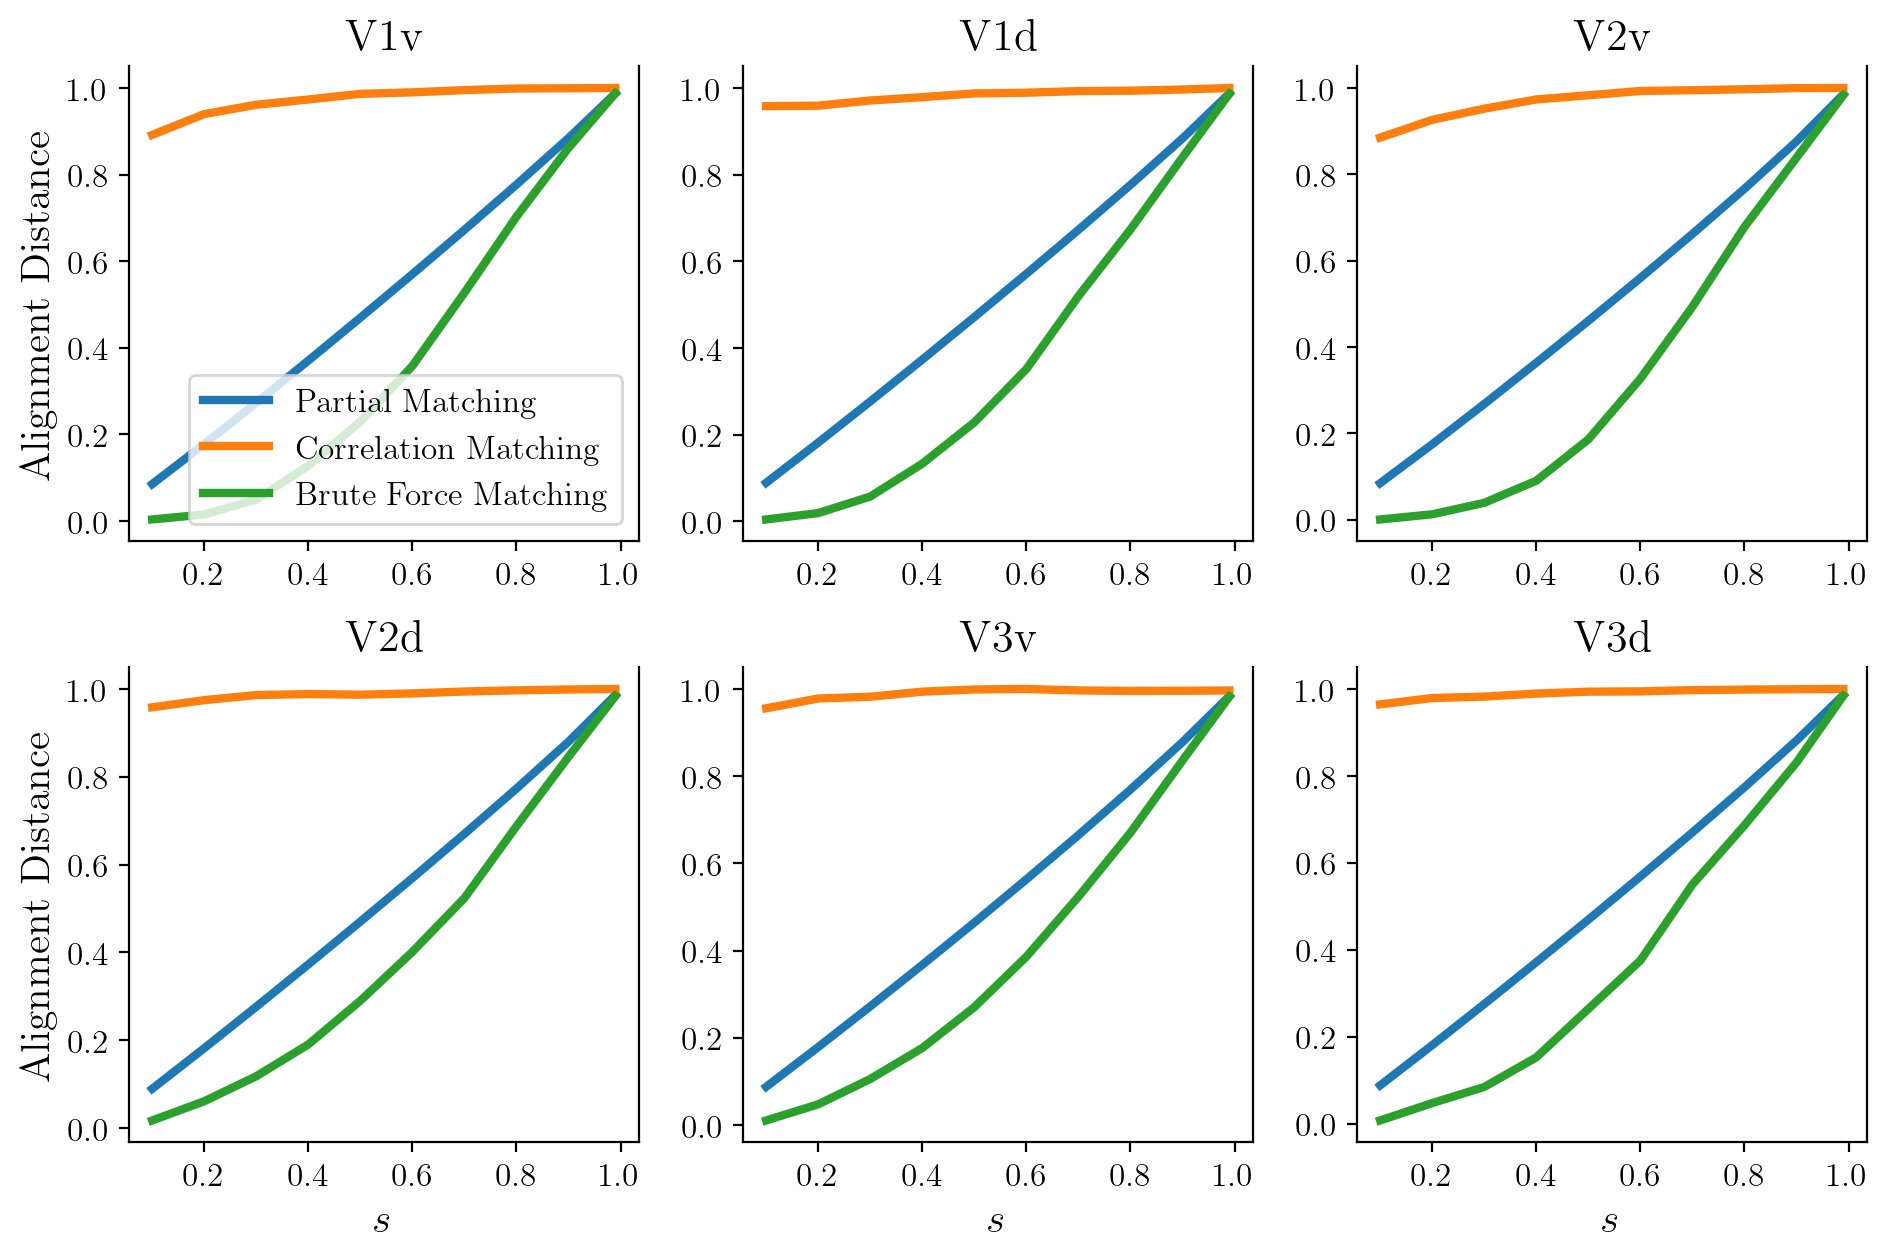

In [39]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12/1.25, 8/1.25))  
axes = axes.flatten()  

for i, region in tqdm(enumerate(brain_regions), total=len(brain_regions)):
    responses = load_voxel_responses(base_path=base_path, brain_region=region)
    r1, r2 = gather_responses(data=responses, subj1=subj1, subj2=subj2)
    # rank ordering of subject 1 -> subject 2
    ##### all matching types
    delta_dict_forward = brute_force_matching_euclidean(torch.tensor(r1), 
                                              torch.tensor(r2))

    # rank ordering of subject 2 -> subject 1
    delta_dict_backward = brute_force_matching_euclidean(torch.tensor(r2), 
                                                   torch.tensor(r1))

    # brute force matching
    mreg_dict_brute_force = align_voxel_responses_both_euclidean(responses1=r1, responses2=r2)
    mreg_dict_brute_force = compute_noise_ceilings_brute_force_euclidean(mreg_dict=mreg_dict_brute_force,
                                            delta_dicts=(delta_dict_forward, delta_dict_backward),
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)
    # correlation matching
    mreg_dict_corr = align_voxel_responses_both_euclidean(responses1=r1, responses2=r2)
    mreg_dict_corr = compute_noise_ceilings_both_euclidean(mreg_dict=mreg_dict_corr,
                                            noise_thresh=0.4, 
                                            transform_thresh=1e-8,
                                            base_path=base_path,
                                            brain_region=region,
                                            responses1=r1,
                                            responses2=r2,
                                            subj1=subj1,
                                            subj2=subj2)
    # partial wasserstein-based matching
    mreg_dict_partial = align_voxel_responses_euclidean(responses1=r1, responses2=r2)
    

    #####
    
    alignment_partial = np.array([mreg_dict_partial[m]['score'] for m in mreg_values[1:]])
    alignment_corr = np.array([mreg_dict_corr[m]['sm_score'] for m in mreg_values[1:]])
    alignment_brute_force = np.array([mreg_dict_brute_force[m]['sm_score'] for m in mreg_values[1:]])

    # normalize distance to be unitary across all 3 techniques
    max_partial = max(alignment_partial)
    max_corr = max(alignment_corr)
    max_brute_force = max(alignment_brute_force)
    norm_factor = max(max_partial, max_corr, max_brute_force)

    print(f'norm factor: {norm_factor}')
    alignment_partial = alignment_partial / norm_factor
    alignment_corr = alignment_corr / norm_factor
    alignment_brute_force = -alignment_brute_force / norm_factor

    #print(alignment_partial, alignment_corr, alignment_brute_force)

    ax1 = axes[i]  # select subplot
    print(alignment_partial, alignment_corr, alignment_brute_force)
    
    # left y-axis: alignment score
    if i > 2:
        #axes[i].set_xlabel(r'$m_\mathrm{reg}$', fontsize=15)
        axes[i].set_xlabel(r"$s$", fontsize=15)
    if i == 0 or i == 3:
        axes[i].set_ylabel('Alignment Distance', fontsize=15)
    axes[i].plot(mreg_values[1:], alignment_partial, linestyle='-', linewidth=3., label='Partial Matching')
    axes[i].plot(mreg_values[1:], alignment_corr, linestyle='-', linewidth=3., label='Correlation Matching')
    axes[i].plot(mreg_values[1:], alignment_brute_force, linestyle='-', linewidth=3., label='Brute Force Matching')
    axes[i].tick_params(axis='both', labelsize=12)
    ax1.spines['top'].set_visible(False)

    # brain region name
    axes[i].set_title(region, fontsize=16, fontweight='bold')

    # combine legends (only in the first subplot)
    if i == 0:
        lines1, labels1 = axes[i].get_legend_handles_labels()
        axes[i].legend(lines1, labels1, loc='best', fontsize=12)

fig.tight_layout()

plt.savefig(f'./paper-figures/nsd-matching-baselines-euclidean.png', dpi=300)
plt.show()
    

# paper figures

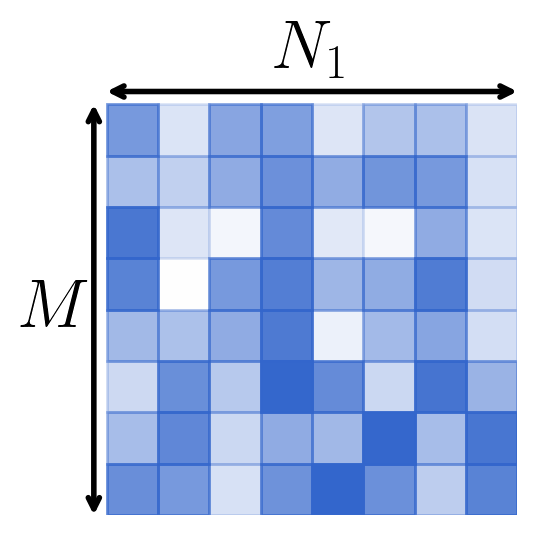

In [139]:
# grid size
nrows, ncols = 8, 8

# base blue color
blue_rgb = (0.2, 0.4, 0.8)

# random alpha values
alphas = np.random.rand(nrows+1, ncols+1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")

# draw the grid of squares
for i in range(nrows):
    for j in range(ncols):
        rect = plt.Rectangle(
            (j, nrows - 1 - i), 1, 1,
            color=blue_rgb, alpha=alphas[i, j]
        )
        ax.add_patch(rect)

# set limits and hide axes (leave a bit of left/top padding for annotations)
ax.set_xlim(-1.0, ncols)
ax.set_ylim(0, nrows + 1.0)
ax.axis("off")

# horizontal double-headed arrow across the top with centered label N_1
y_arrow = nrows + 0.25
ax.annotate(
    '',
    xy=(ncols, y_arrow), xytext=(0, y_arrow),
    arrowprops=dict(arrowstyle='<->', linewidth=2.0, color='k', shrinkA=0, shrinkB=0)
)
ax.text(ncols / 2, y_arrow + 0.2, r'$N_1$', ha='center', va='bottom', fontsize=25)

# vertical double-headed line on the left with centered label M
x_line = -0.25
ax.annotate(
    '',
    xy=(x_line, nrows), xytext=(x_line, 0),
    arrowprops=dict(arrowstyle='<->', linewidth=2.0, color='k', shrinkA=0, shrinkB=0)
)
ax.text(x_line - 0.8, nrows / 2, r'$M$', ha='center', va='center', fontsize=25)

plt.savefig(f'./paper-figures/schematic-response-a.png', dpi=300)

plt.show()


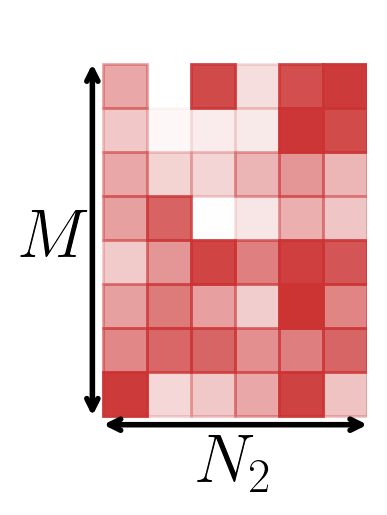

In [159]:
# grid size
nrows, ncols = 8, 6

# base blue color
blue_rgb = (0.8, 0.2, 0.2)

# random alpha values
alphas = np.random.rand(nrows+1, ncols+1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")

# draw the grid of squares
for i in range(nrows):
    for j in range(ncols):
        rect = plt.Rectangle(
            (j, nrows - 1 - i), 1, 1,
            color=blue_rgb, alpha=alphas[i, j]
        )
        ax.add_patch(rect)

# set limits and hide axes (leave a bit of left/top padding for annotations)
ax.set_xlim(-1.0, ncols)
#ax.set_ylim(0, nrows + 1.0)
ax.set_ylim(-1.5, nrows + 1.0) 
ax.axis("off")

# horizontal double-headed arrow across the top with centered label N_1
"""
y_arrow = nrows + 0.25
ax.annotate(
    '',
    xy=(ncols, y_arrow), xytext=(0, y_arrow),
    arrowprops=dict(arrowstyle='<->', linewidth=2.0, color='k', shrinkA=0, shrinkB=0)
)
ax.text(ncols / 2, y_arrow + 0.2, r'$N_2$', ha='center', va='bottom', fontsize=25)
"""
y_arrow = nrows - 8.2 # place below the grid
ax.annotate(
    '',
    xy=(ncols, y_arrow), xytext=(0, y_arrow),
    arrowprops=dict(arrowstyle='<->', linewidth=2.0, color='k', shrinkA=0, shrinkB=0)
)
ax.text(ncols / 2, y_arrow - 0.2, r'$N_2$', ha='center', va='top', fontsize=25)


# vertical double-headed line on the left with centered label M
x_line = -0.25
ax.annotate(
    '',
    xy=(x_line, nrows), xytext=(x_line, 0),
    arrowprops=dict(arrowstyle='<->', linewidth=2.0, color='k', shrinkA=0, shrinkB=0)
)
ax.text(x_line - 0.9, nrows / 2, r'$M$', ha='center', va='center', fontsize=25)

plt.savefig(f'./paper-figures/schematic-response-b.png', dpi=300)

plt.show()
